In [1]:
from glob import glob
from analysis_utlis import *
from other_utlis import *

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

evaluation_*.csv
       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.000431      6.038705
1     butina         RMSE       0.009127      4.321067
2     butina          MAE       0.007852      4.181851
3     butina     PearsonR       0.990585      1.360174
4     butina  SpearmanRho       0.983669      1.545690
5     random           R2       0.033704      3.343978
6     random         RMSE       0.221036      2.033854
7     random          MAE       0.189212      2.061123
8     random     PearsonR       0.682282      1.355227
9     random  SpearmanRho       0.984723      1.252217
10  scaffold           R2       0.055996      2.734180
11  scaffold         RMSE       0.675442      1.337866
12  scaffold          MAE       0.750988      1.265310
13  scaffold     PearsonR       0.249874      1.839330
14  scaffold  SpearmanRho       0.636880      1.213038


/home/ashj/miniconda3/envs/ml_analysis/lib/python3.9/site-packages/scikit_posthocs/_posthocs.py:735: RuntimeWarning: divide by zero encountered in scalar divide
  tval = dif / np.sqrt(A) / np.sqrt(B)
/home/ashj/miniconda3/envs/ml_analysis/lib/python3.9/site-packages/scikit_posthocs/_posthocs.py:735: RuntimeWarning: divide by zero encountered in scalar divide
  tval = dif / np.sqrt(A) / np.sqrt(B)
/home/ashj/miniconda3/envs/ml_analysis/lib/python3.9/site-packages/scikit_posthocs/_posthocs.py:735: RuntimeWarning: divide by zero encountered in scalar divide
  tval = dif / np.sqrt(A) / np.sqrt(B)
/home/ashj/miniconda3/envs/ml_analysis/lib/python3.9/site-packages/scikit_posthocs/_posthocs.py:735: RuntimeWarning: divide by zero encountered in scalar divide
  tval = dif / np.sqrt(A) / np.sqrt(B)
/home/ashj/miniconda3/envs/ml_analysis/lib/python3.9/site-packages/scikit_posthocs/_posthocs.py:735: RuntimeWarning: divide by zero encountered in scalar divide
  tval = dif / np.sqrt(A) / np.sqrt(B)


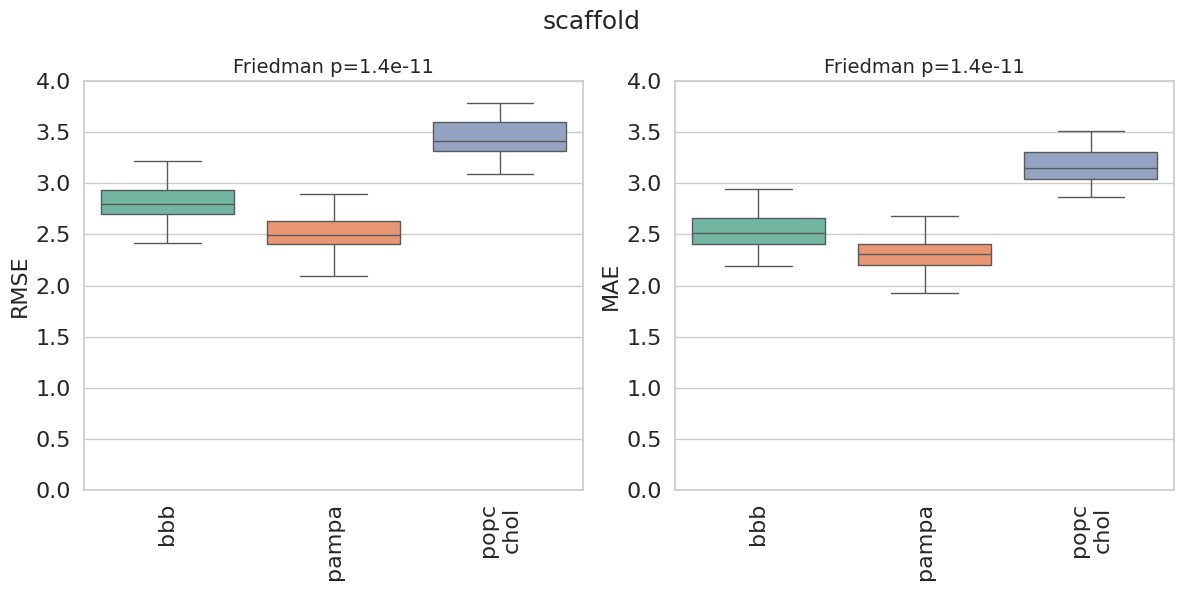

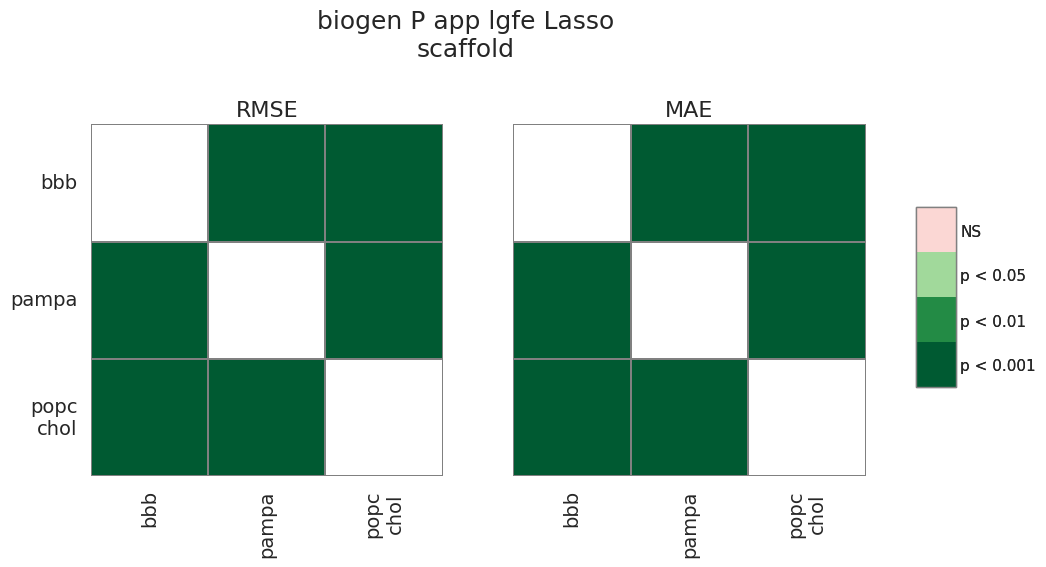

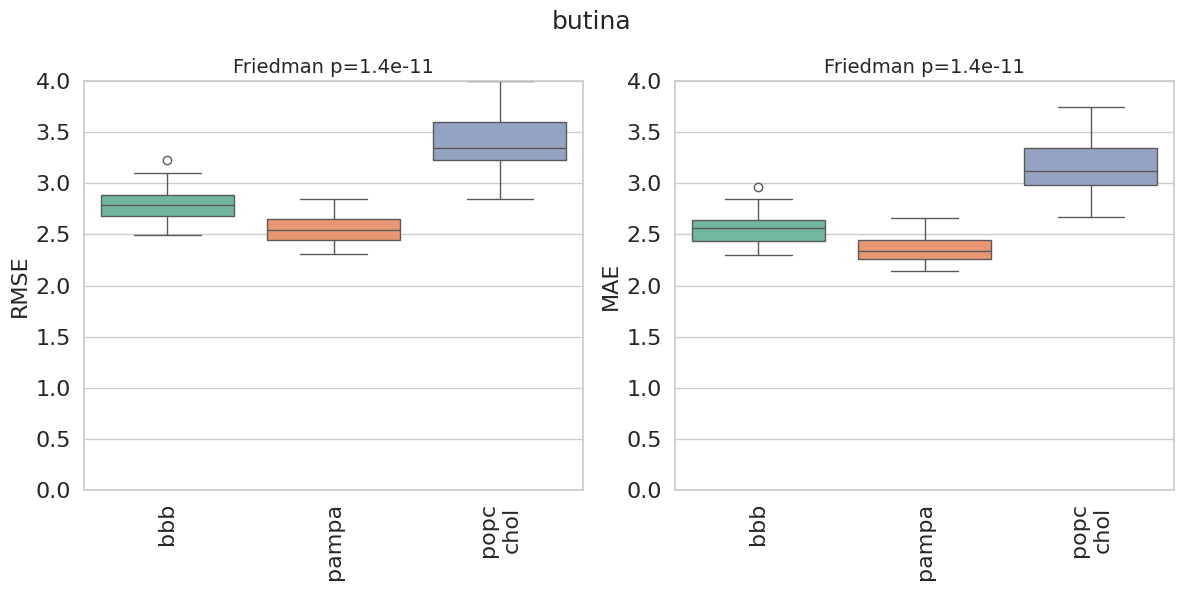

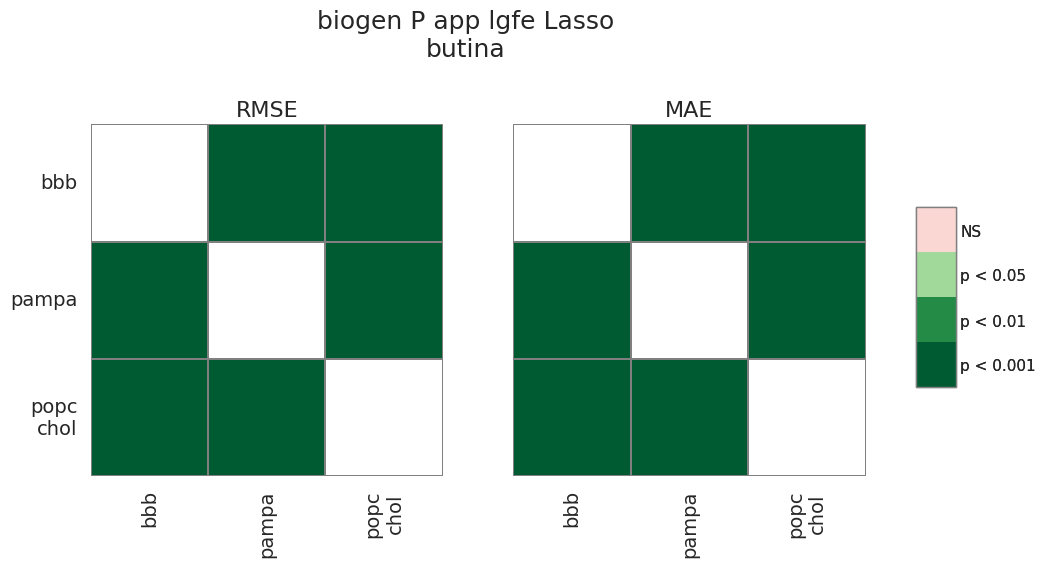

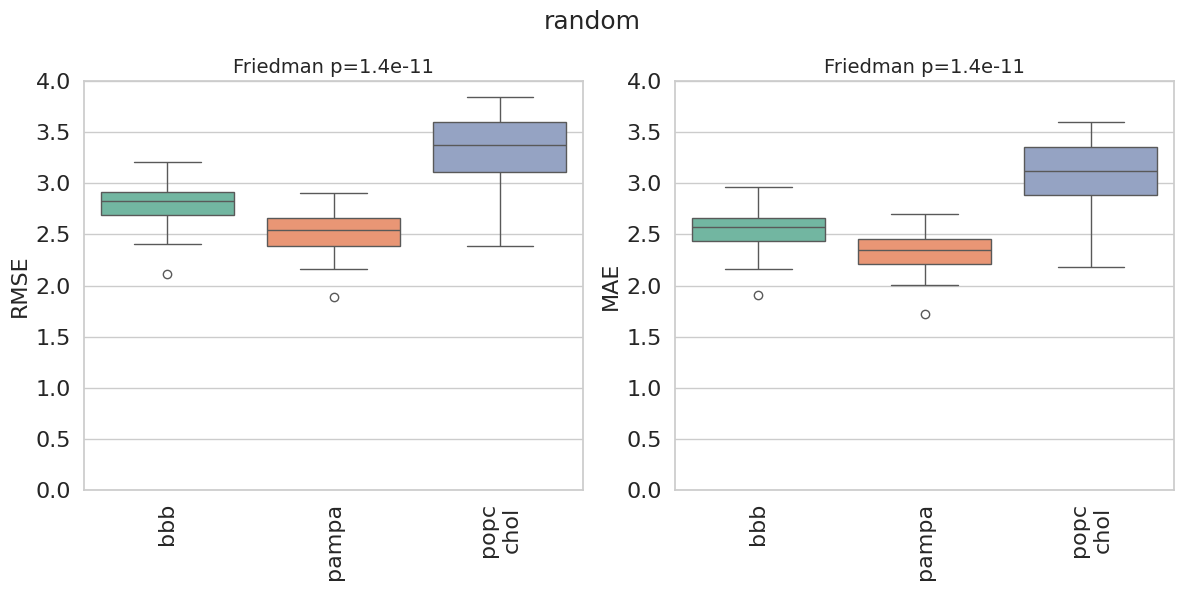

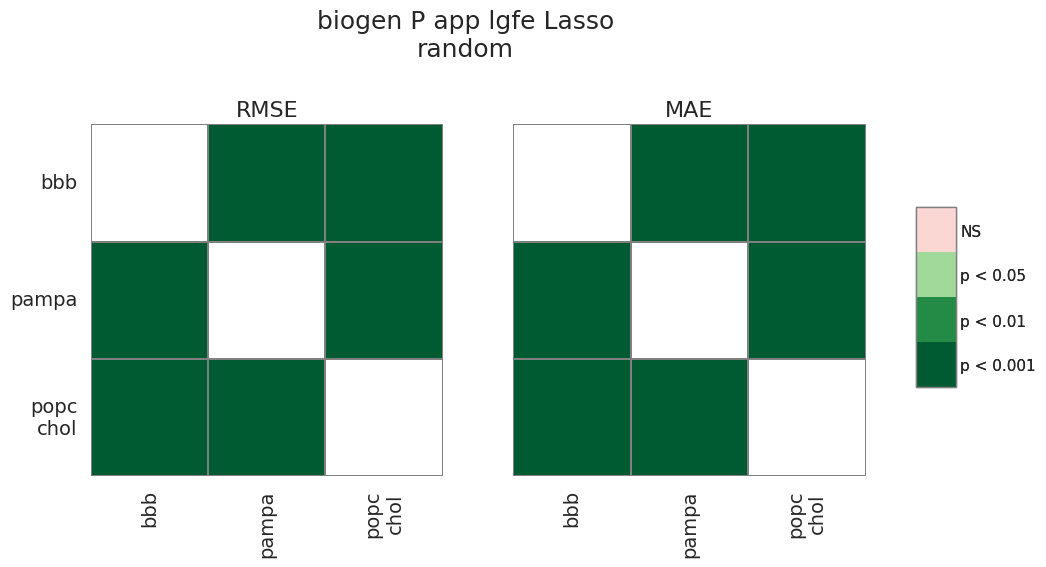

In [6]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_base/evaluation/Lasso/evaluation_*.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    print (Path(csv_file[0]).name)
    print (levene_variance_df)
    # metric_ls = ['PearsonR', 'RMSE', 'MAE']
    metric_ls = ['RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/lasso_across_membs_P_app", common_prefix="-biogen-P_app_lgfe_Lasso")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/lasso_across_membs_P_app", common_prefix="-biogen-P_app_lgfe_Lasso")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots/lasso_across_membs_P_app/Levene_variance_results.xlsx"
)

evaluation_*.csv
       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.000210      9.058893
1     butina         RMSE       0.008024      5.350599
2     butina          MAE       0.008300      5.235165
3     butina     PearsonR       0.510997      1.185573
4     butina  SpearmanRho       0.412287      1.359248
5     random           R2       0.016827      9.997153
6     random         RMSE       0.029149      5.268667
7     random          MAE       0.042690      5.708925
8     random     PearsonR       0.812561      1.352471
9     random  SpearmanRho       0.438857      1.460652
10  scaffold           R2       0.001299      6.858310
11  scaffold         RMSE       0.001803      4.296571
12  scaffold          MAE       0.006021      3.703591
13  scaffold     PearsonR       0.736861      1.933465
14  scaffold  SpearmanRho       0.622189      1.578774


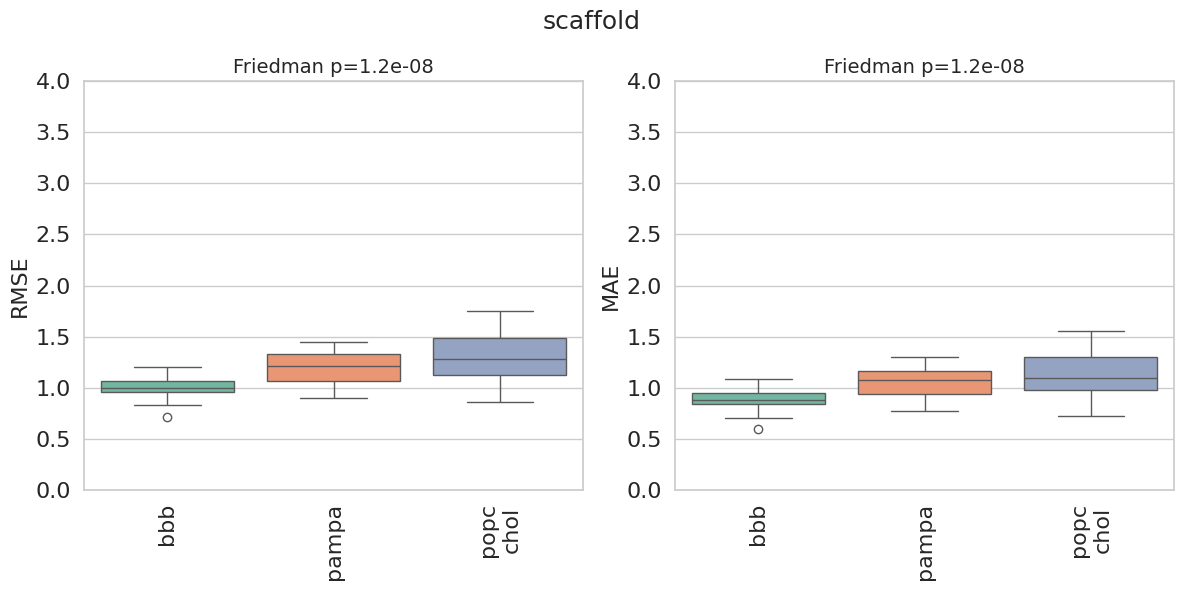

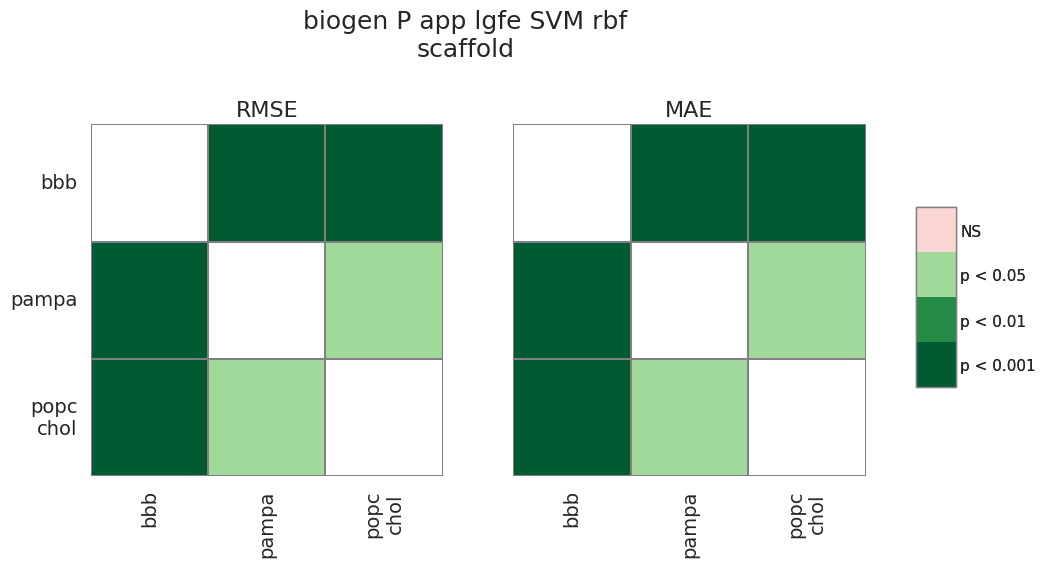

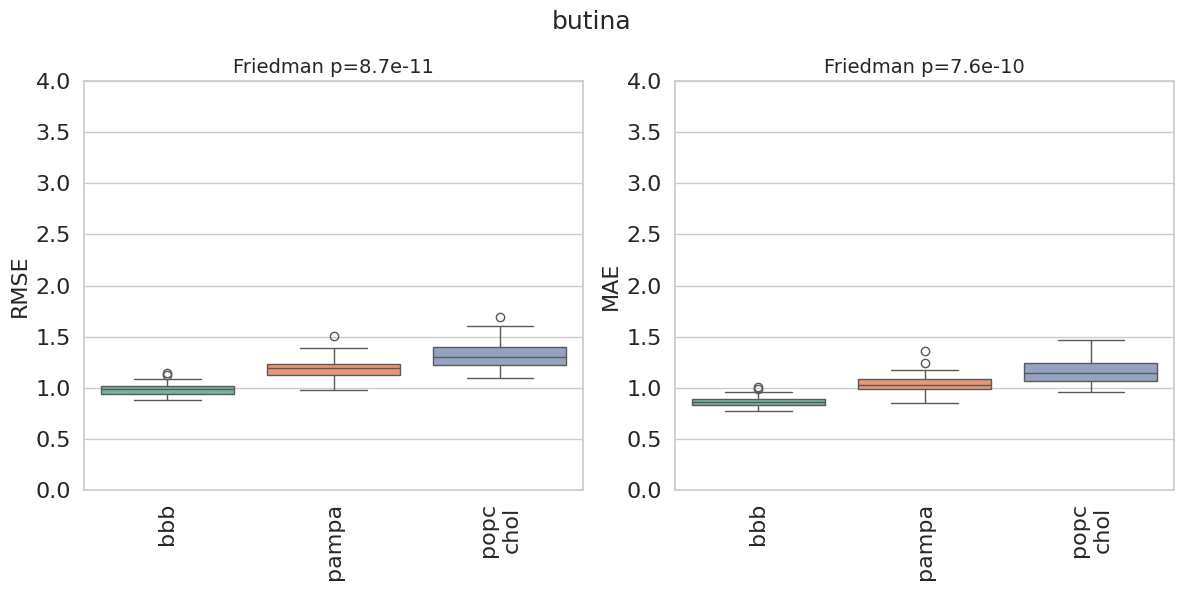

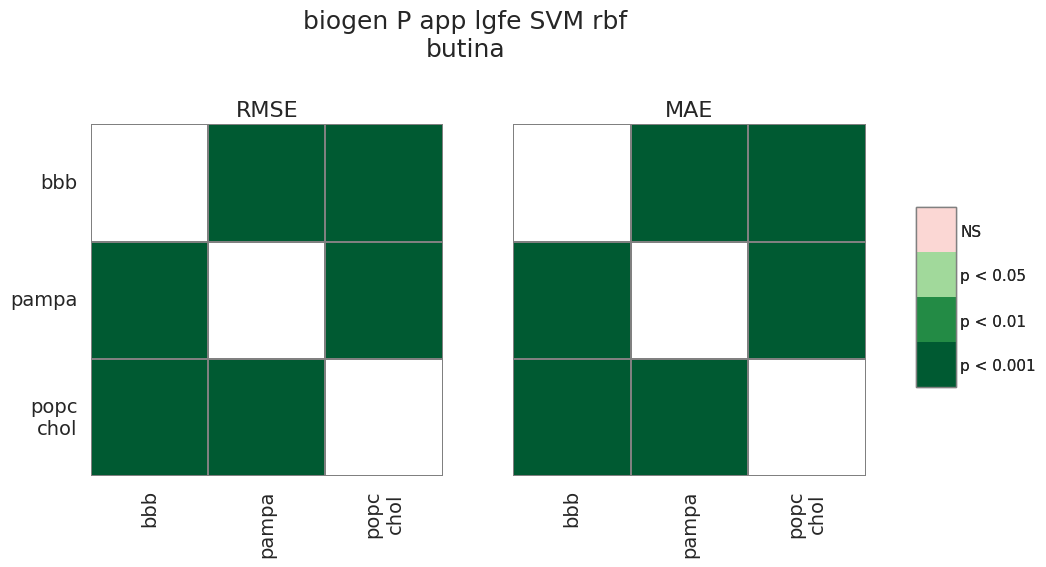

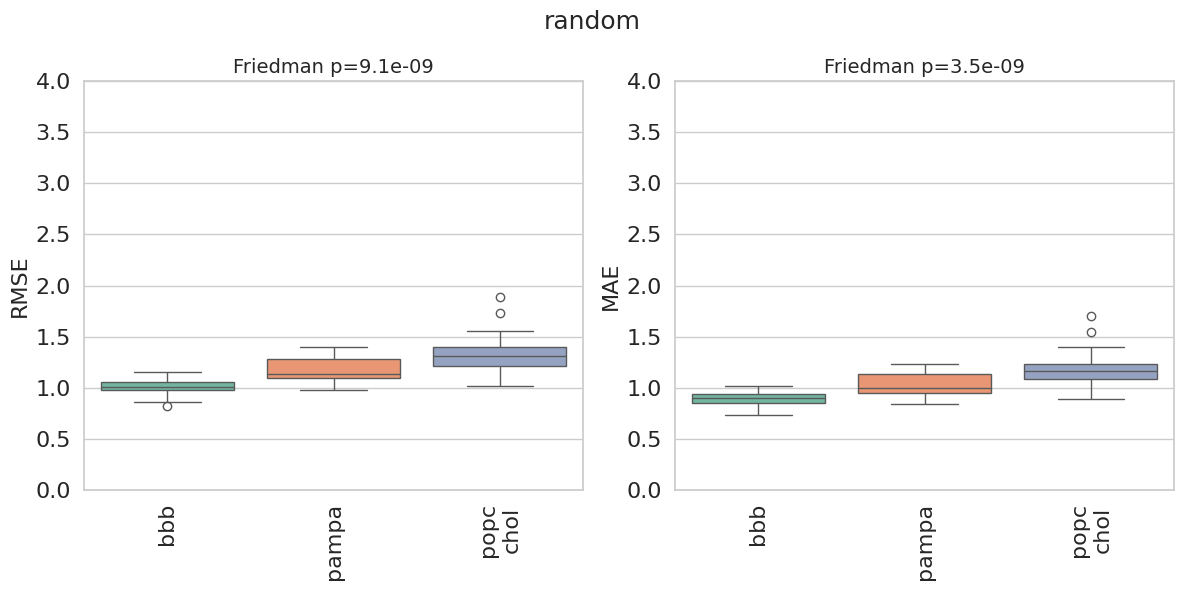

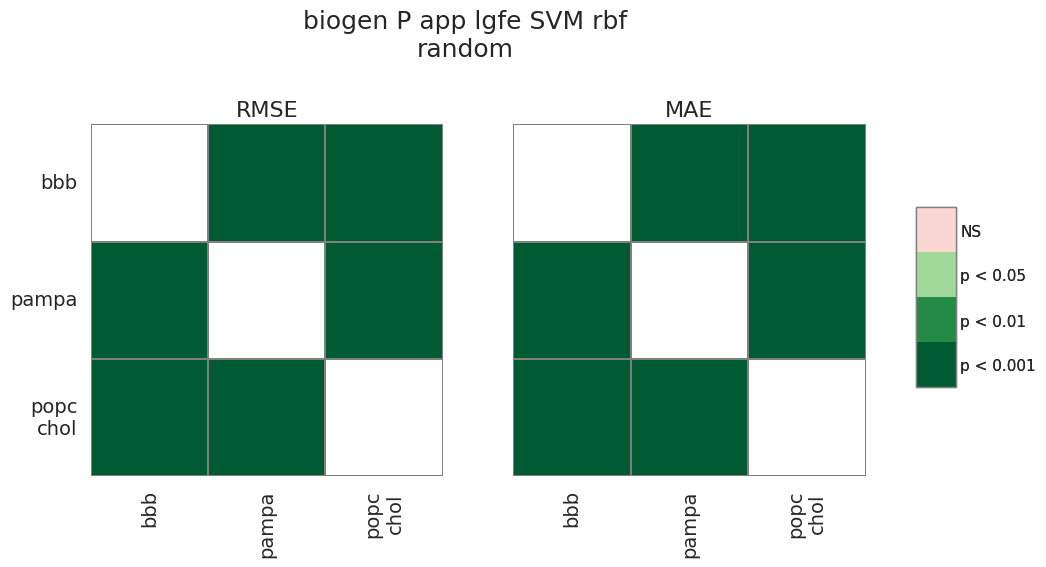

In [7]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_base/evaluation/SVM_rbf/evaluation_*.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    print (Path(csv_file[0]).name)
    print (levene_variance_df)
    # metric_ls = ['PearsonR', 'RMSE', 'MAE']
    metric_ls = ['RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/svm_rbf_across_membs_P_app", common_prefix="-biogen-P_app_lgfe_SVM_rbf")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/svm_rbf_across_membs_P_app", common_prefix="-biogen-P_app_lgfe_SVM_rbf")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots/svm_rbf_across_membs_P_app/Levene_variance_results.xlsx"
)

### P_app prediction with Hybrid LGFE profiles

#### 1. FCNN

#### 1. A. Is there a better FCNN architecture? 

TLDR : Not really, the archs under this study are not significantly different in performance (using non-parameteric testing) - irrespective of what kind of data spliting strategy used

In [2]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN/evaluation_popc_chol.csv"],
                  ["../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN/evaluation_popc_chol_halogen.csv"],
                  ["../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN/evaluation_pampa.csv"],
                  ["../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN/evaluation_bbb.csv"]]


/home/ashj/projects/permeation-project/ml_analysis/analysis_utlis.py:326: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


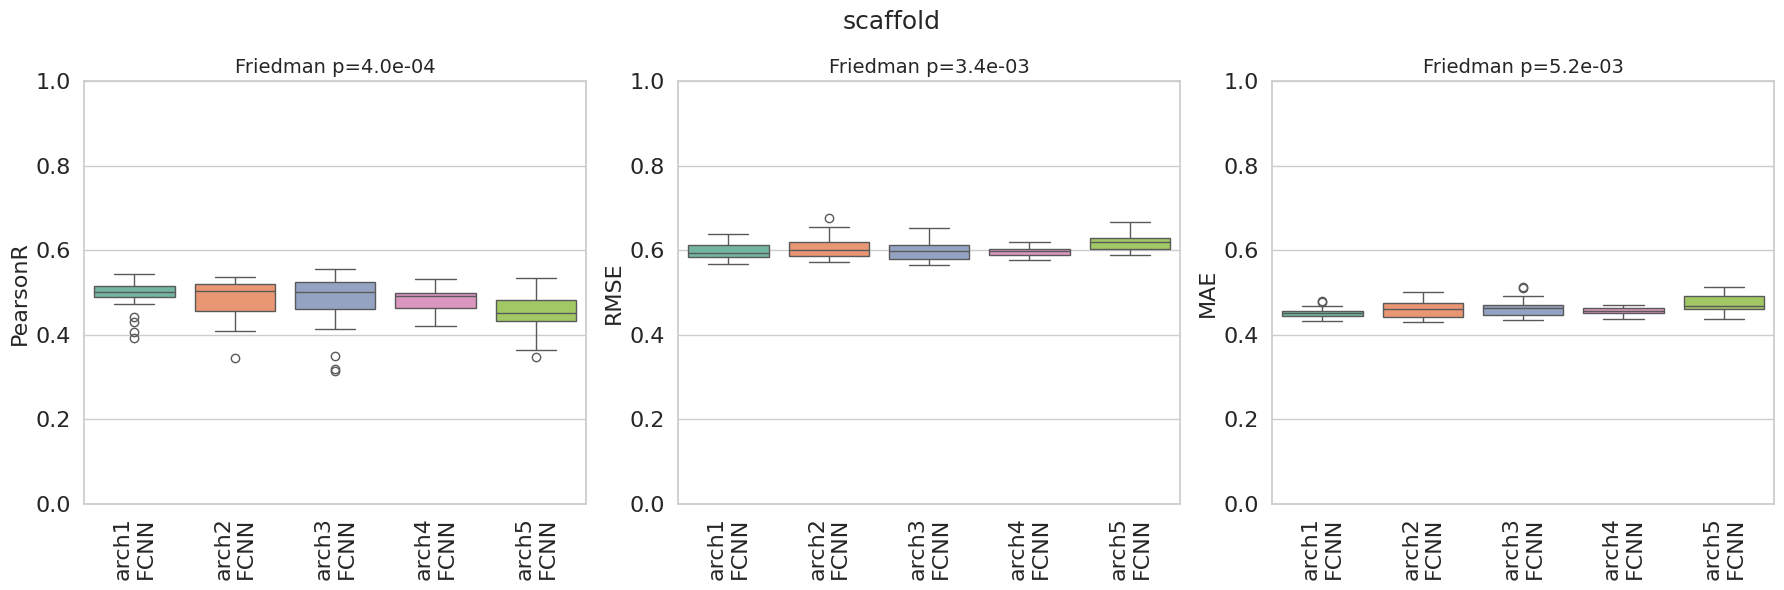

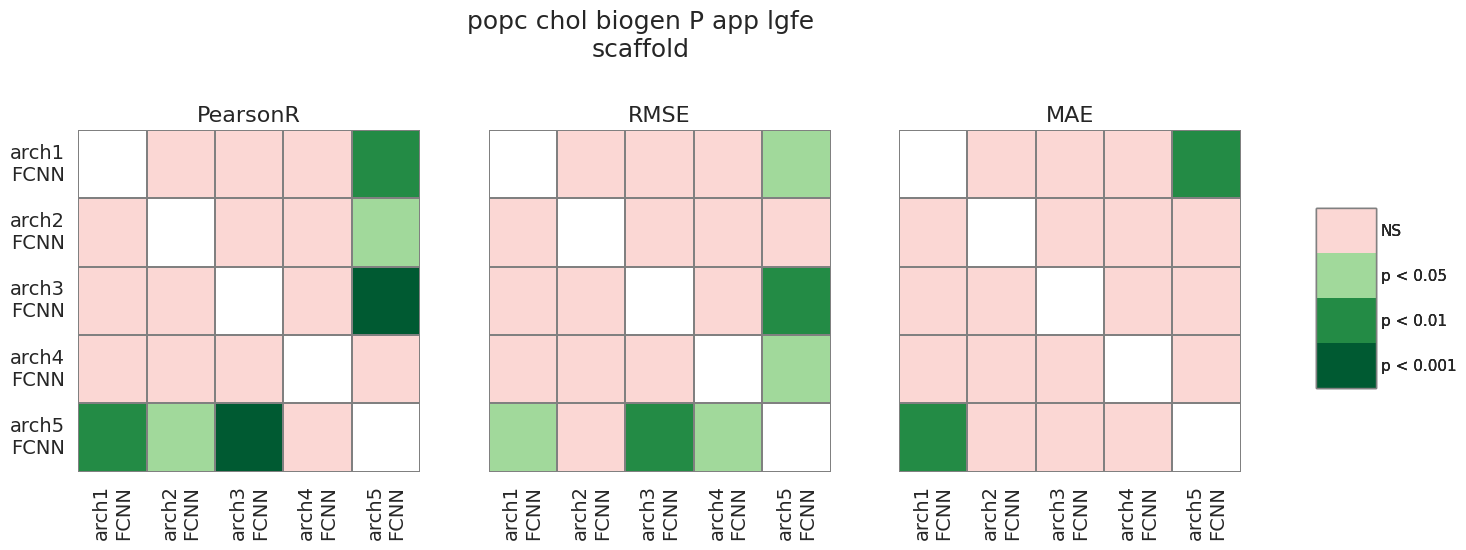

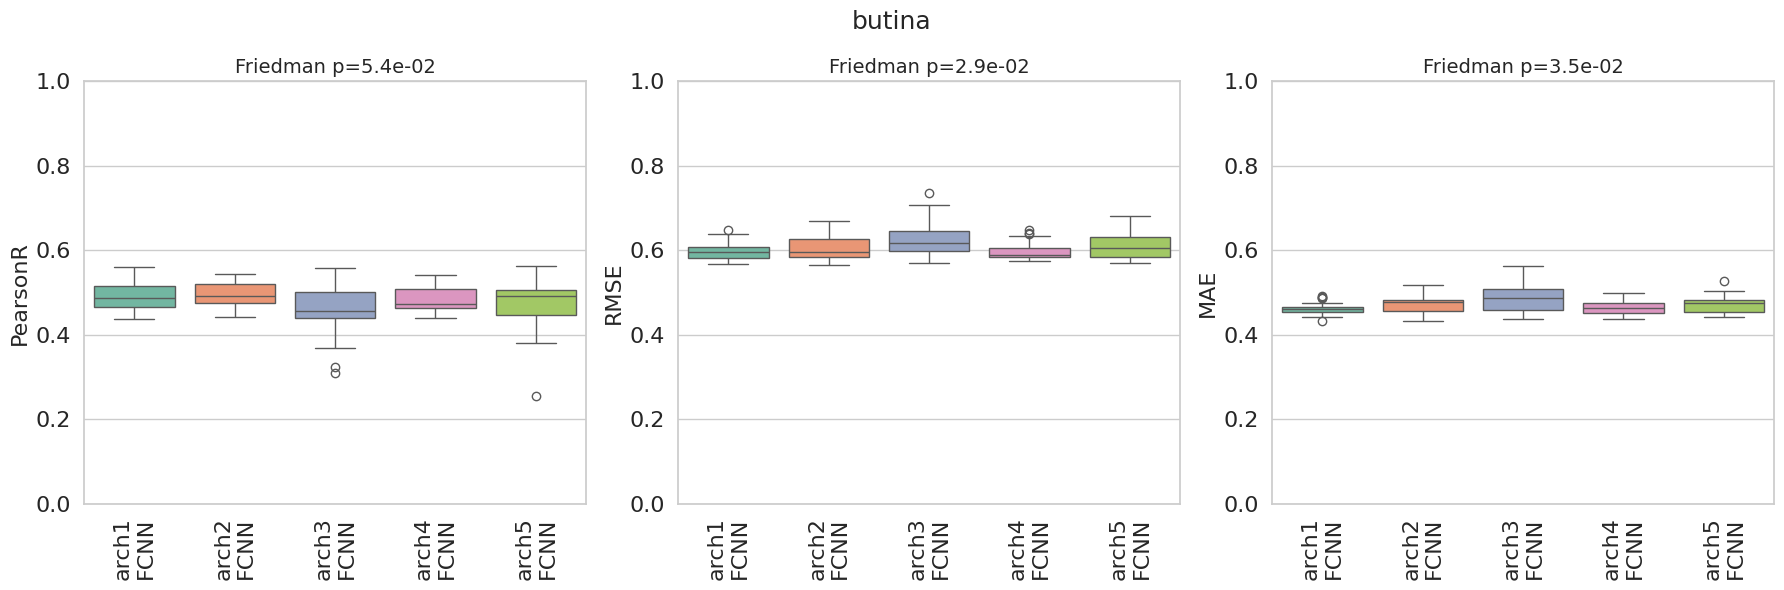

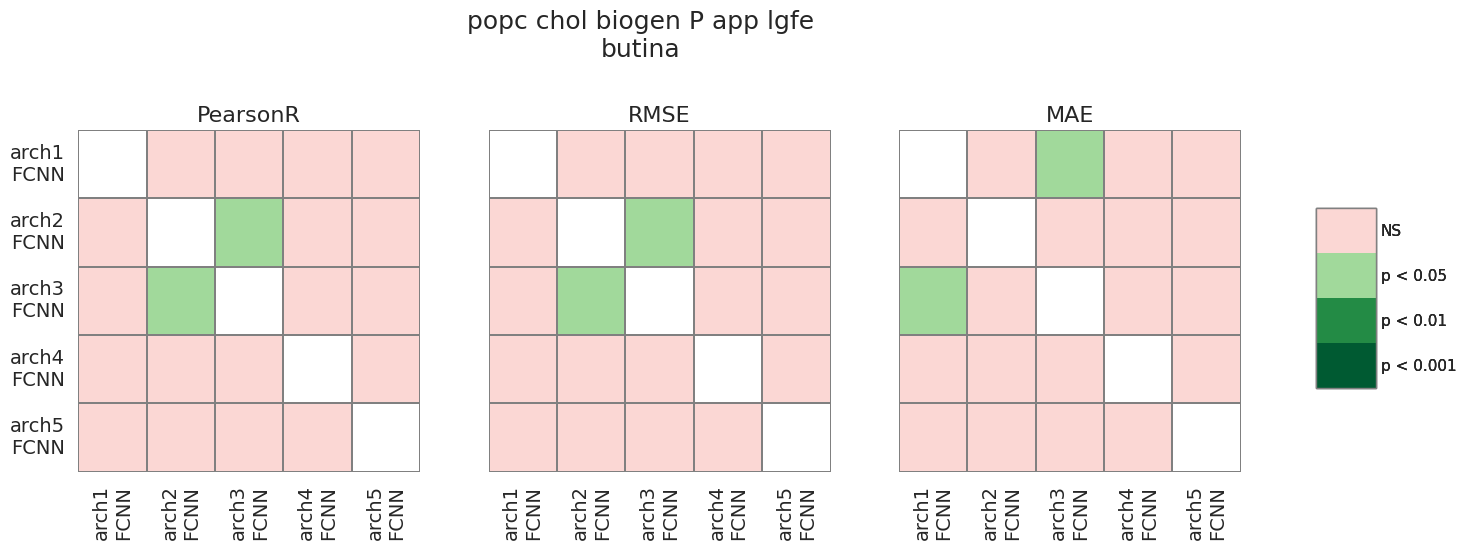

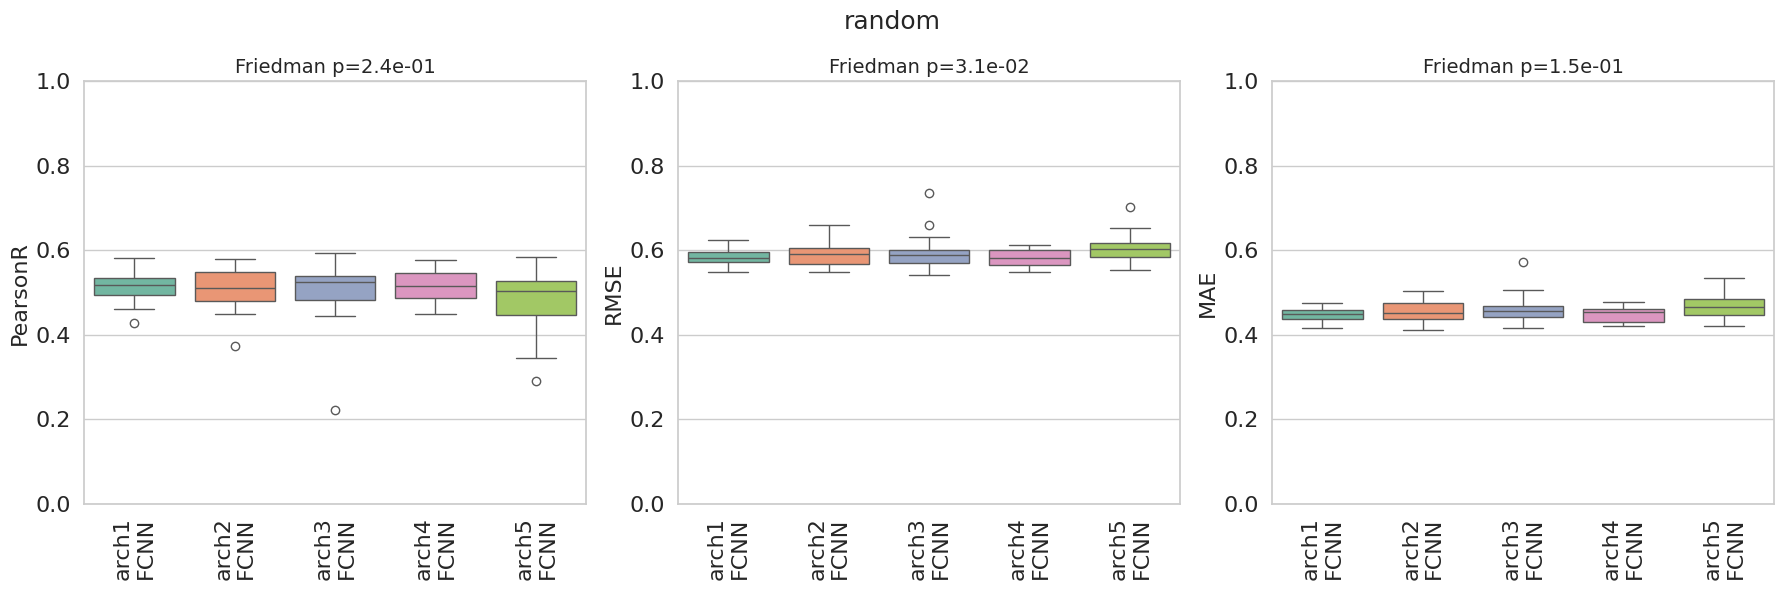

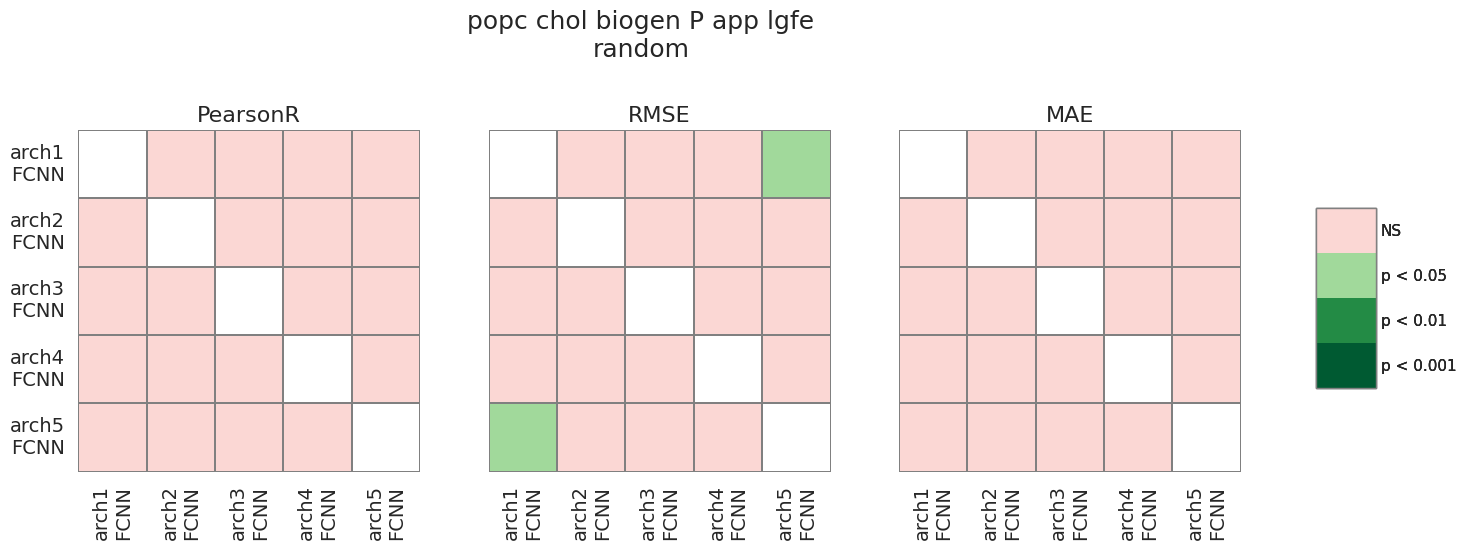

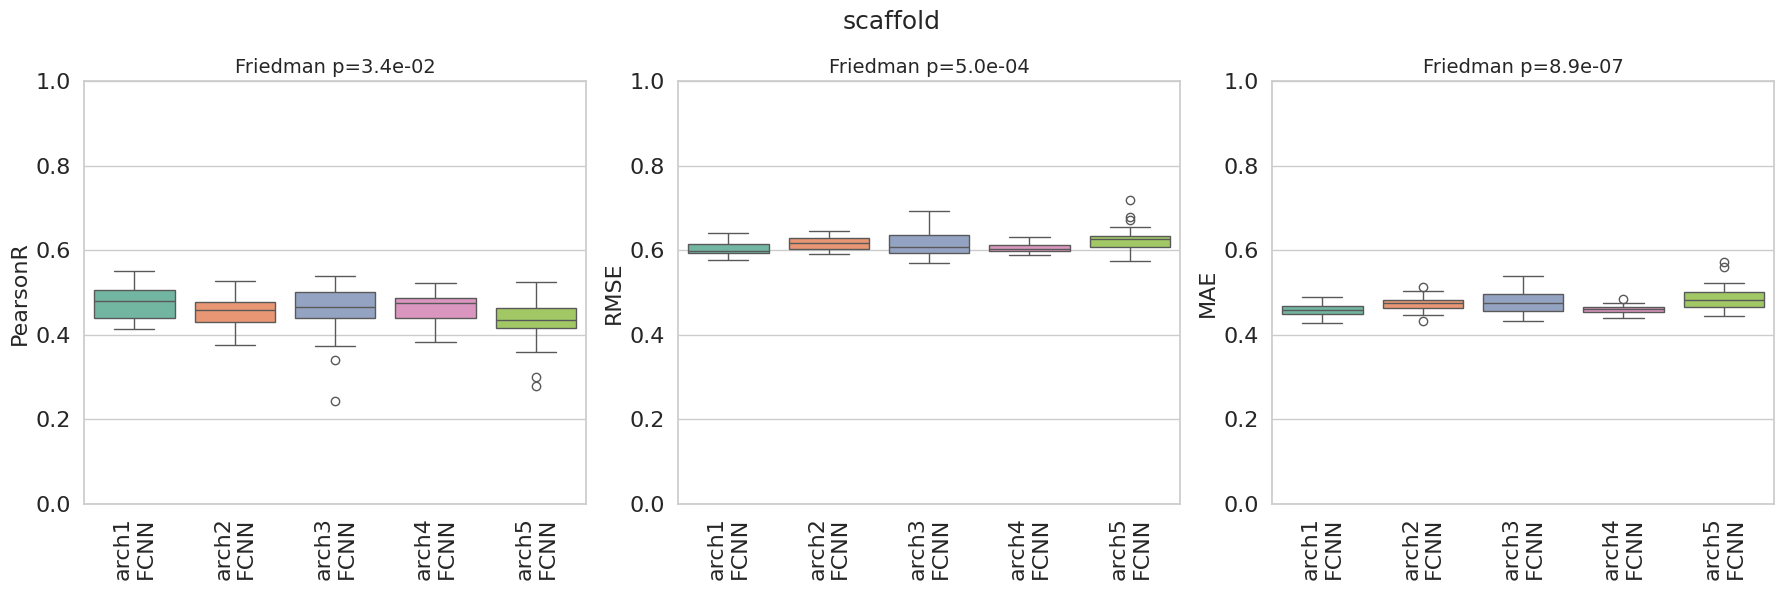

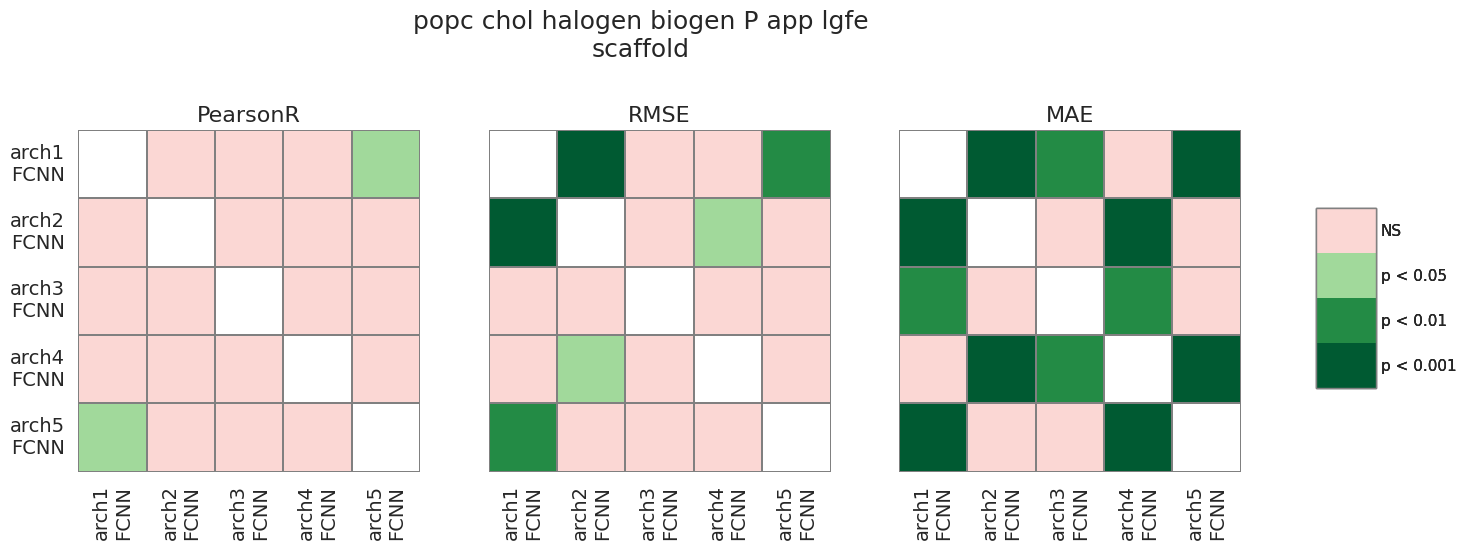

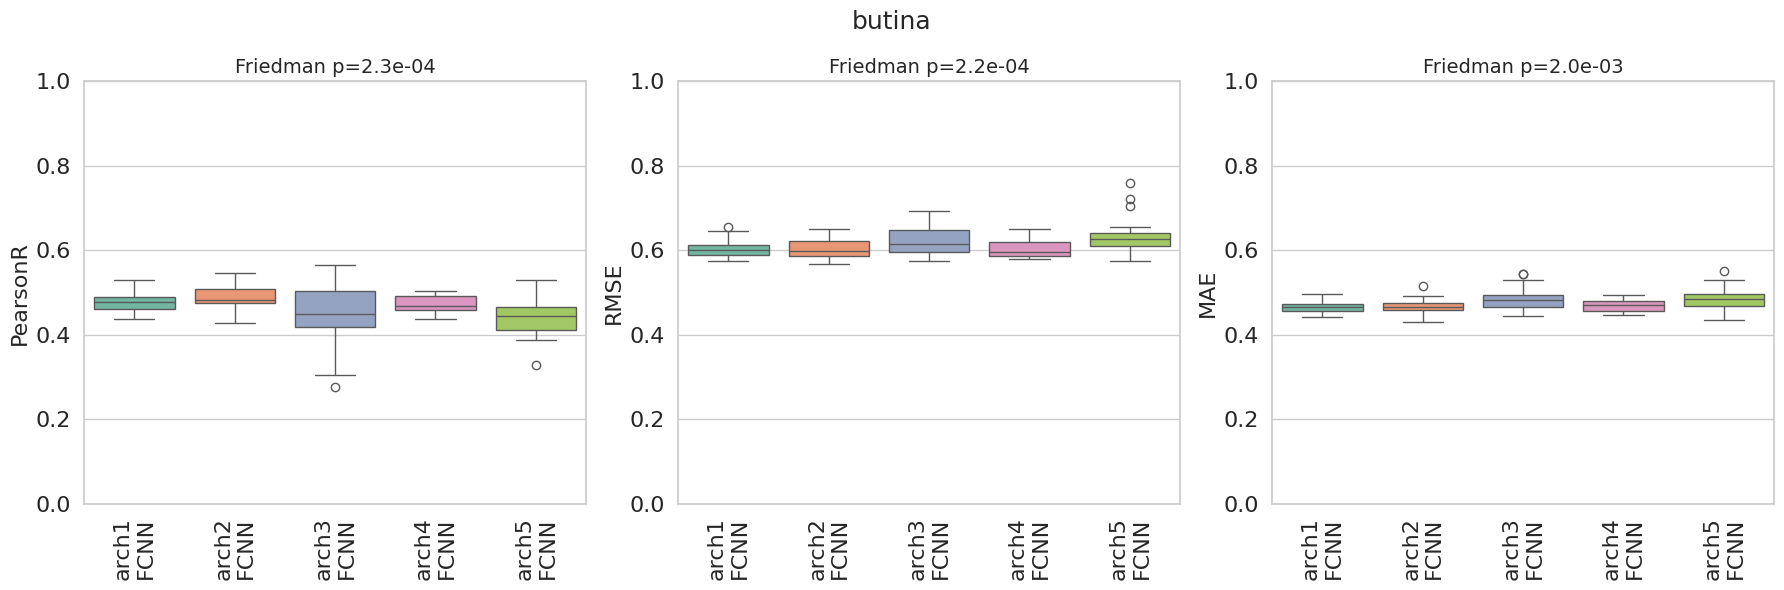

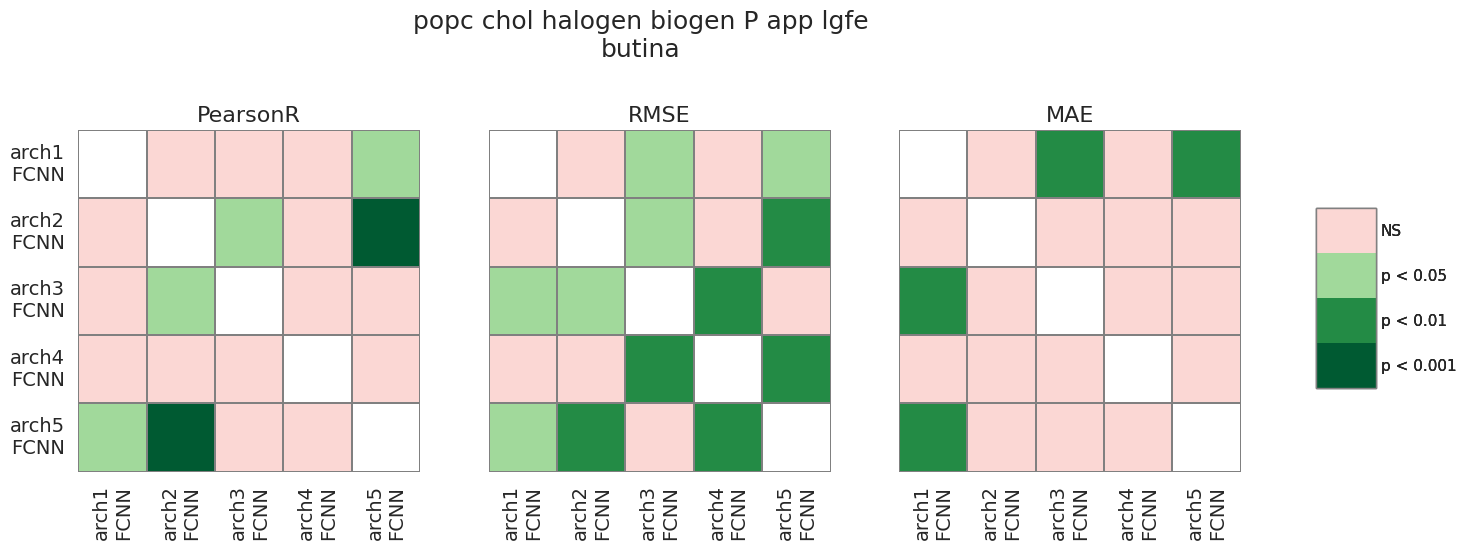

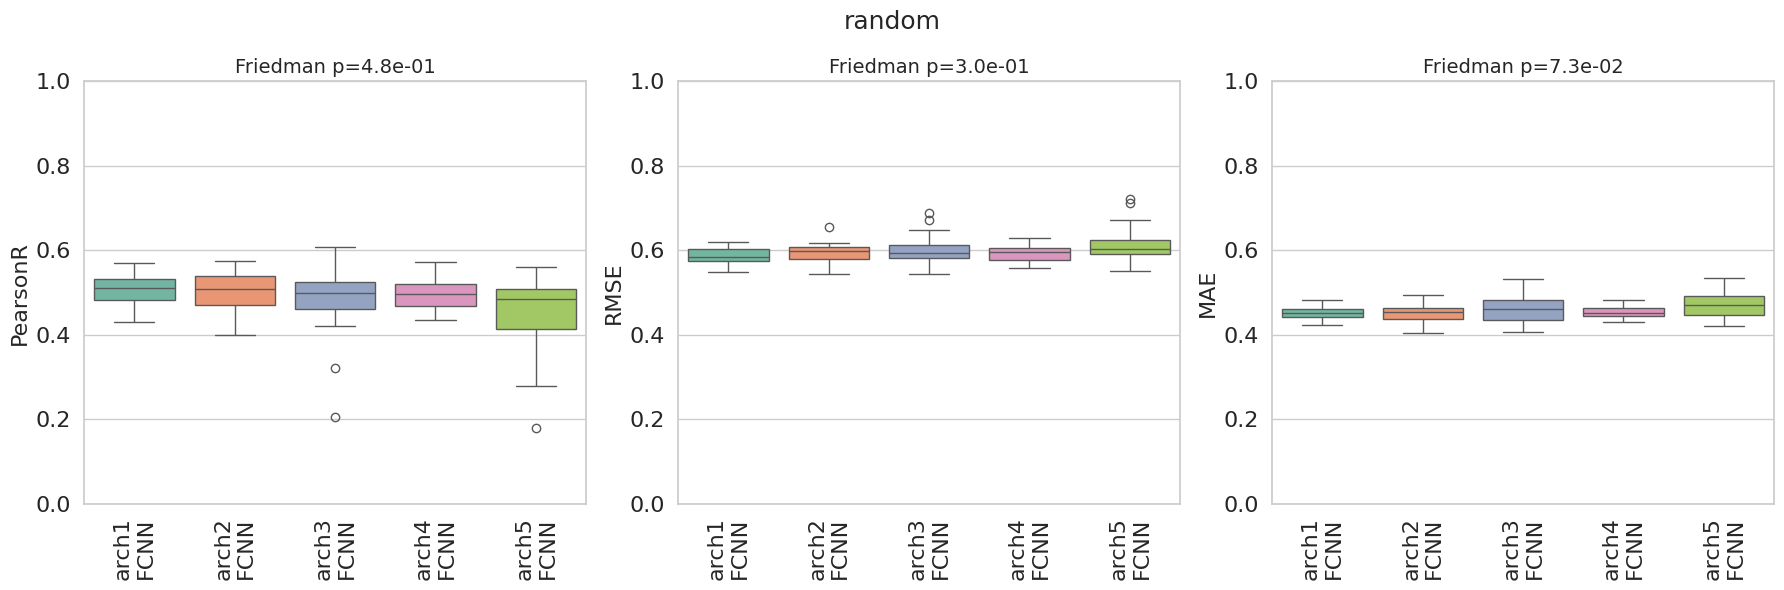

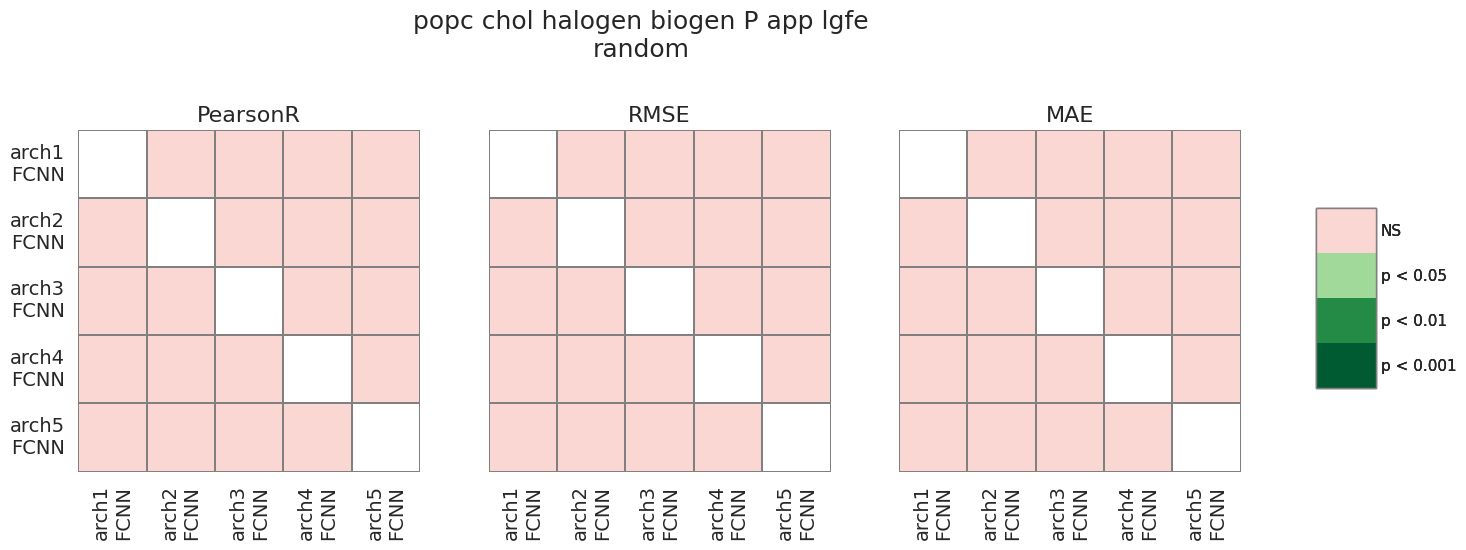

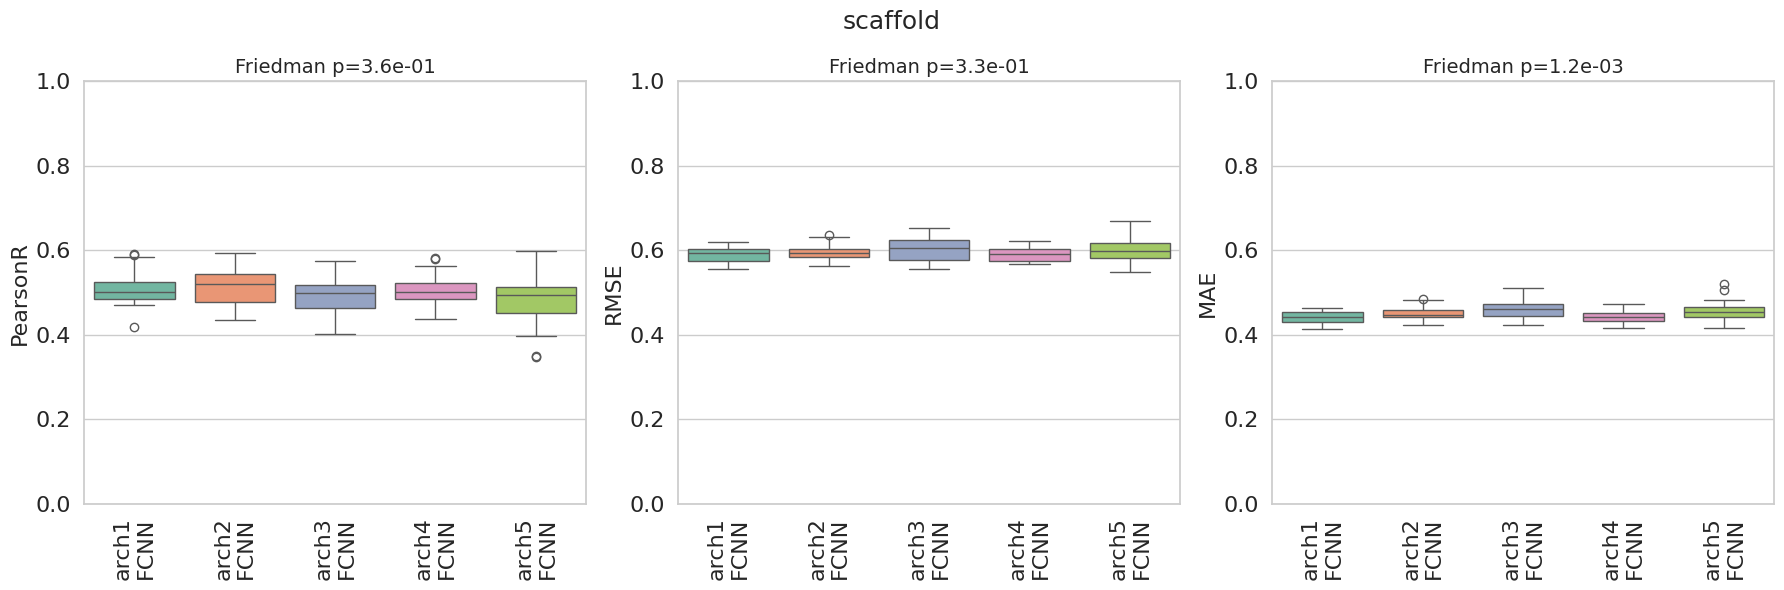

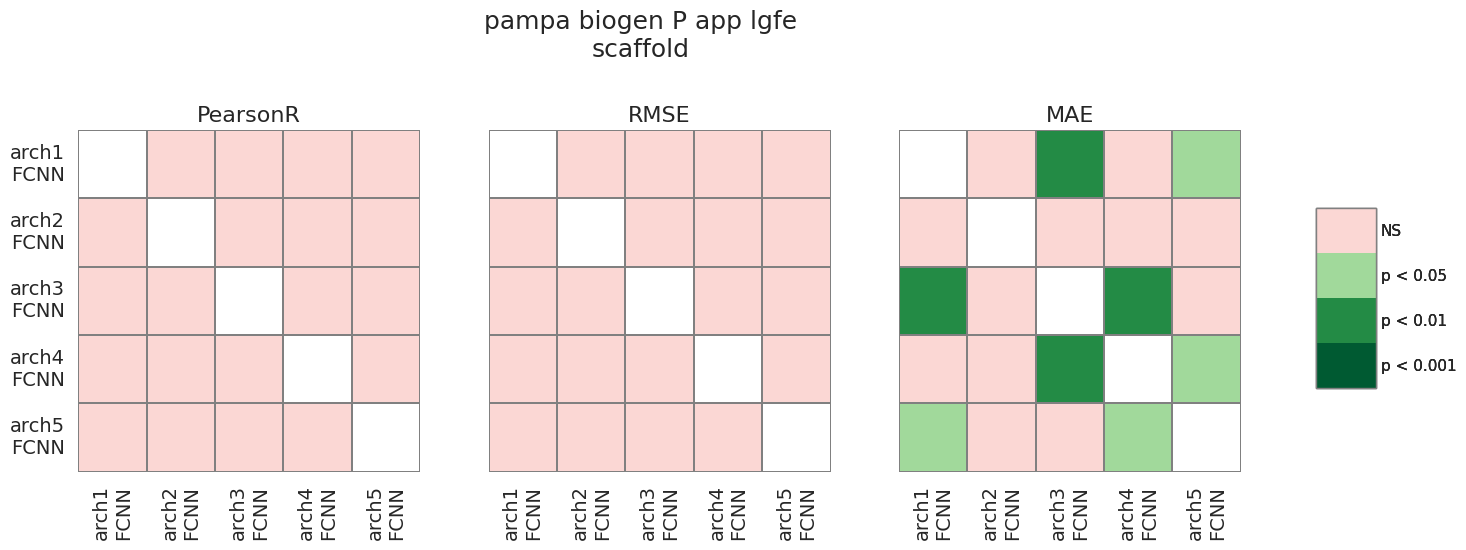

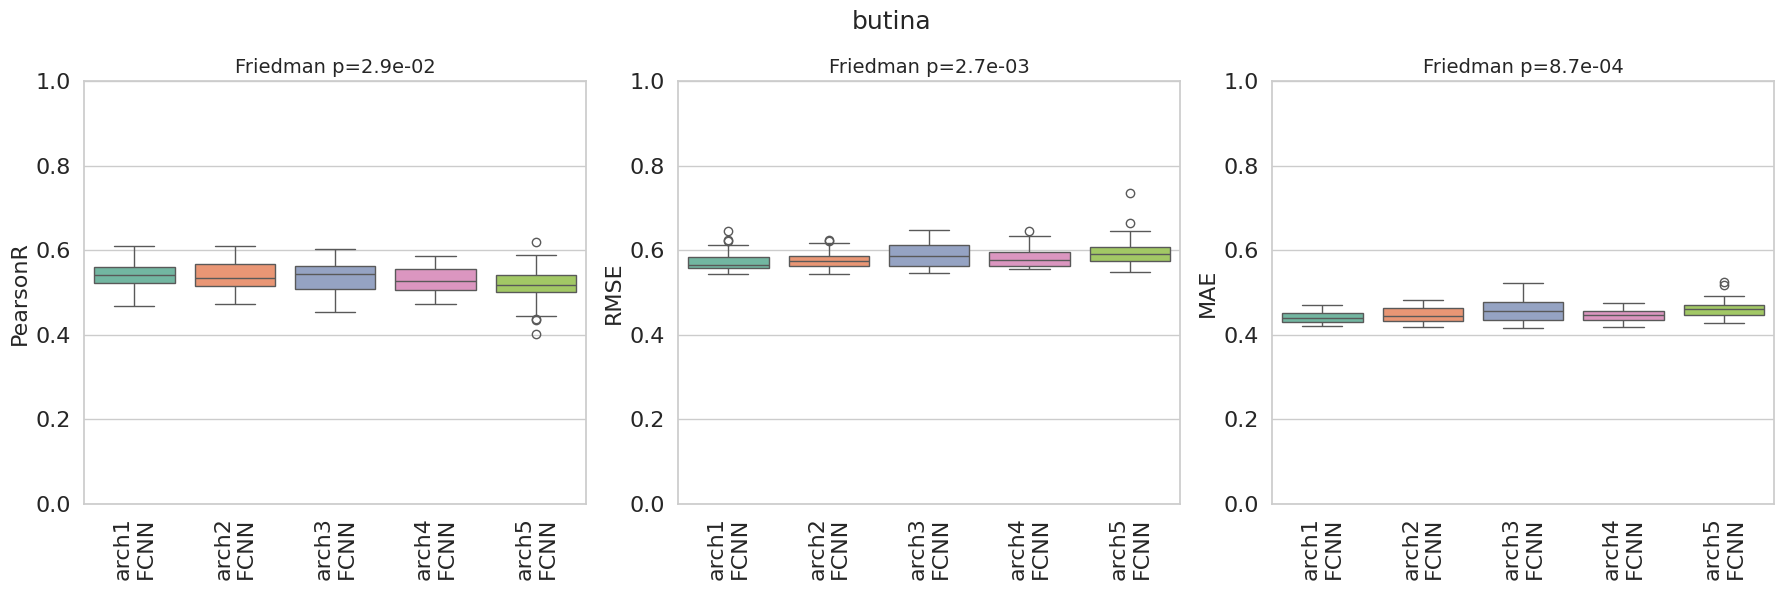

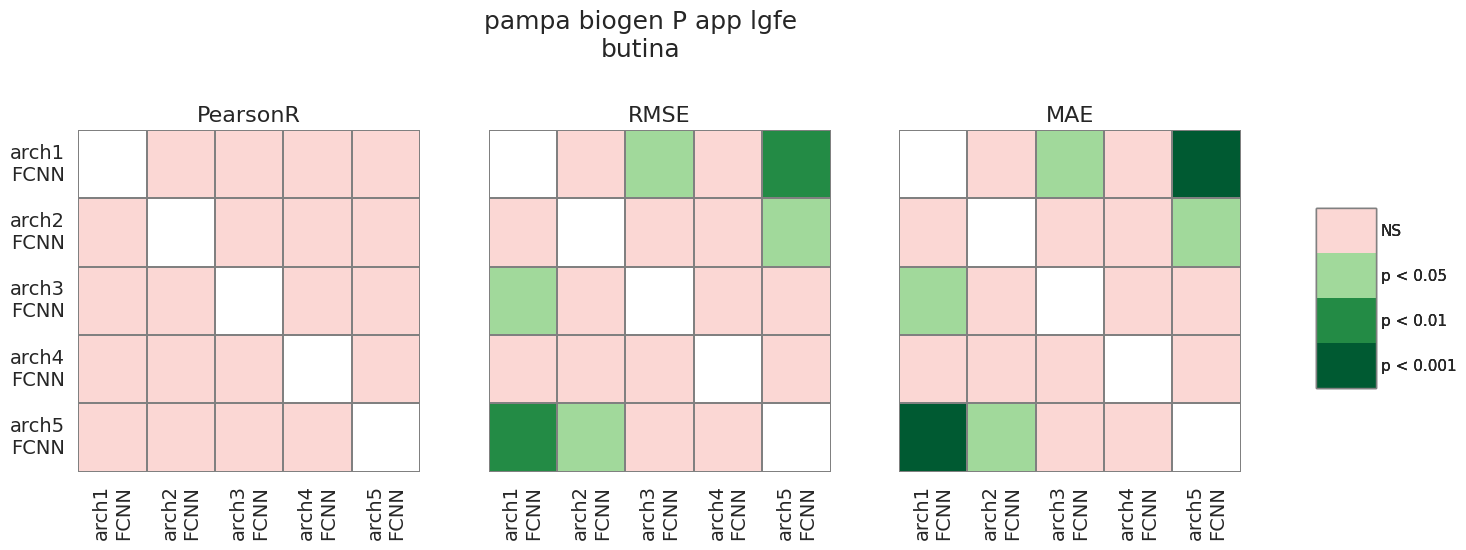

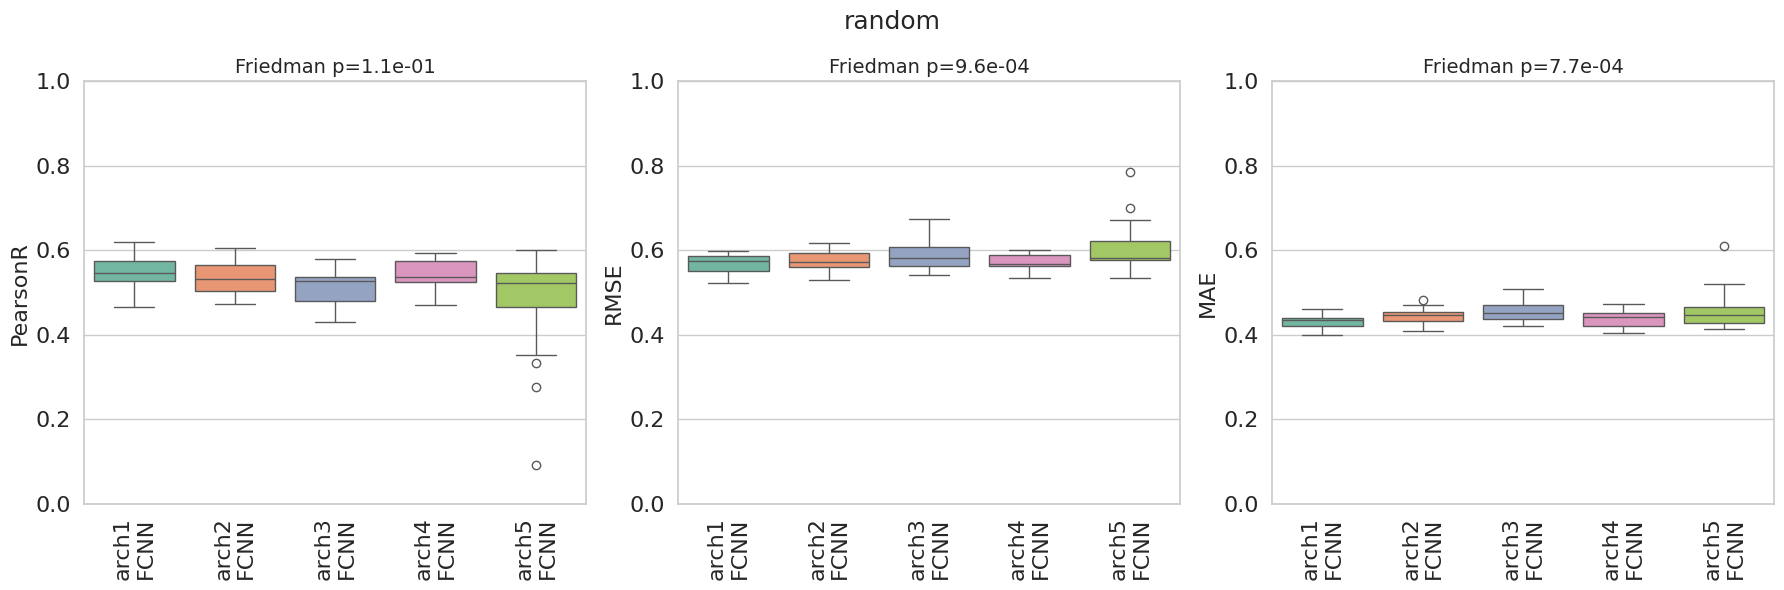

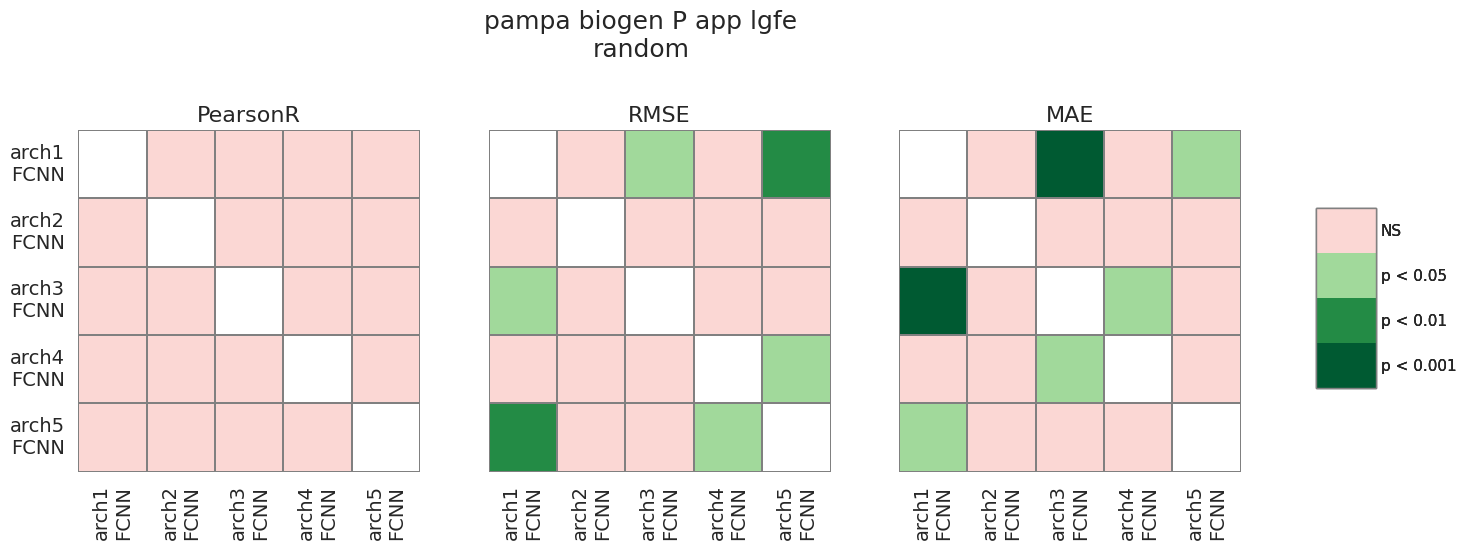

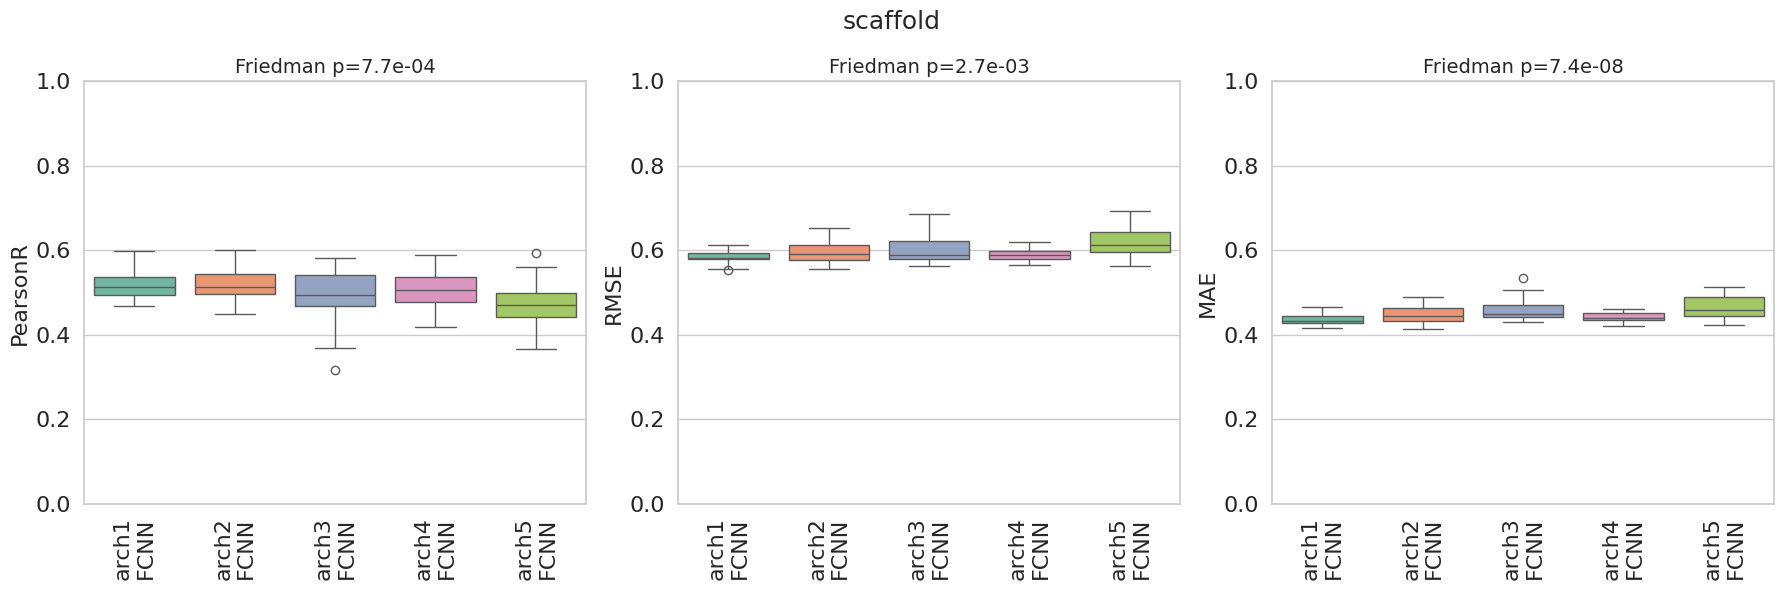

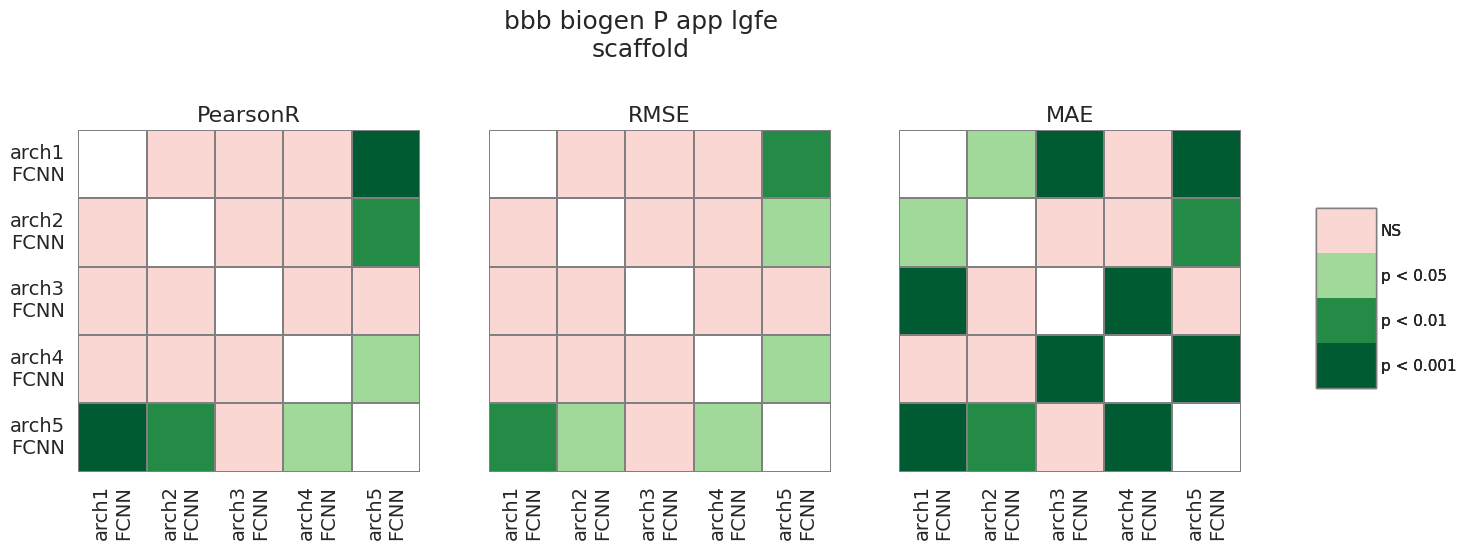

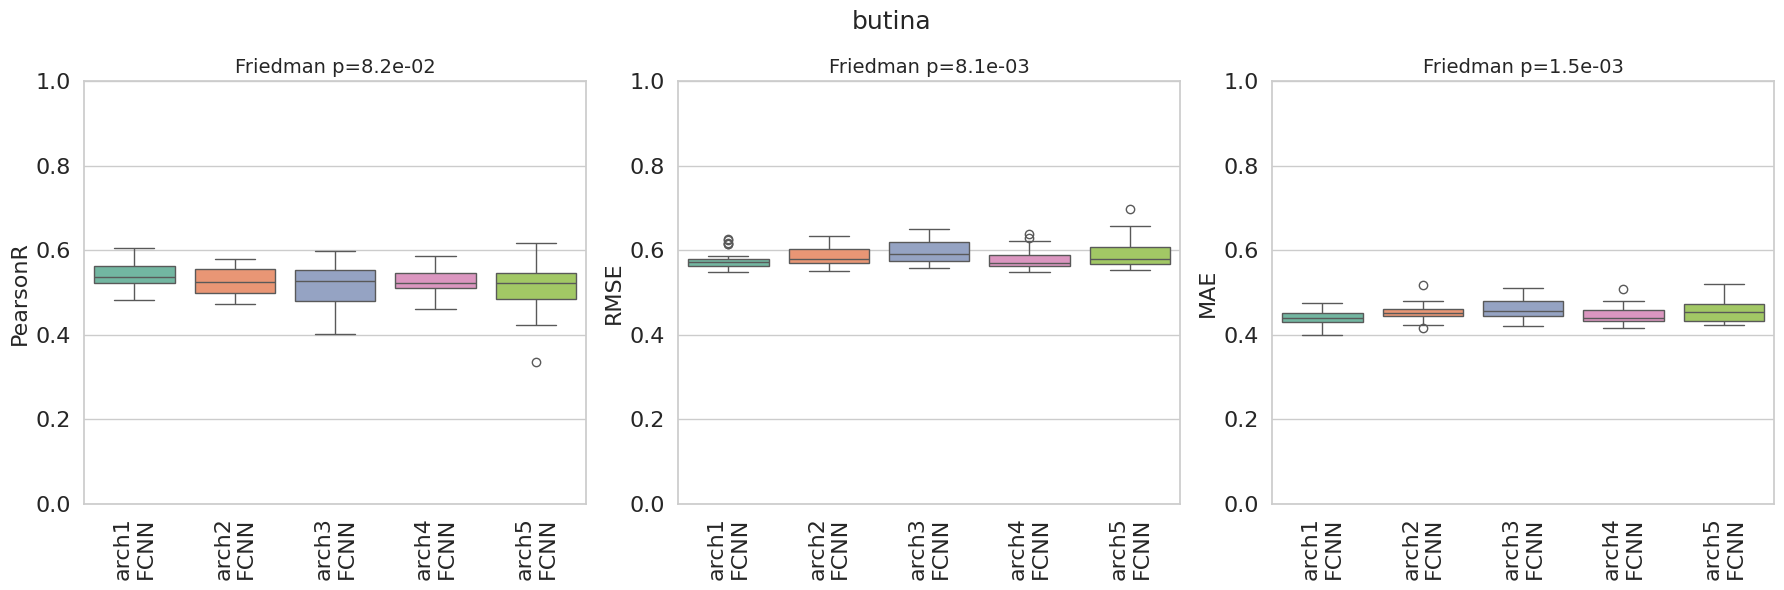

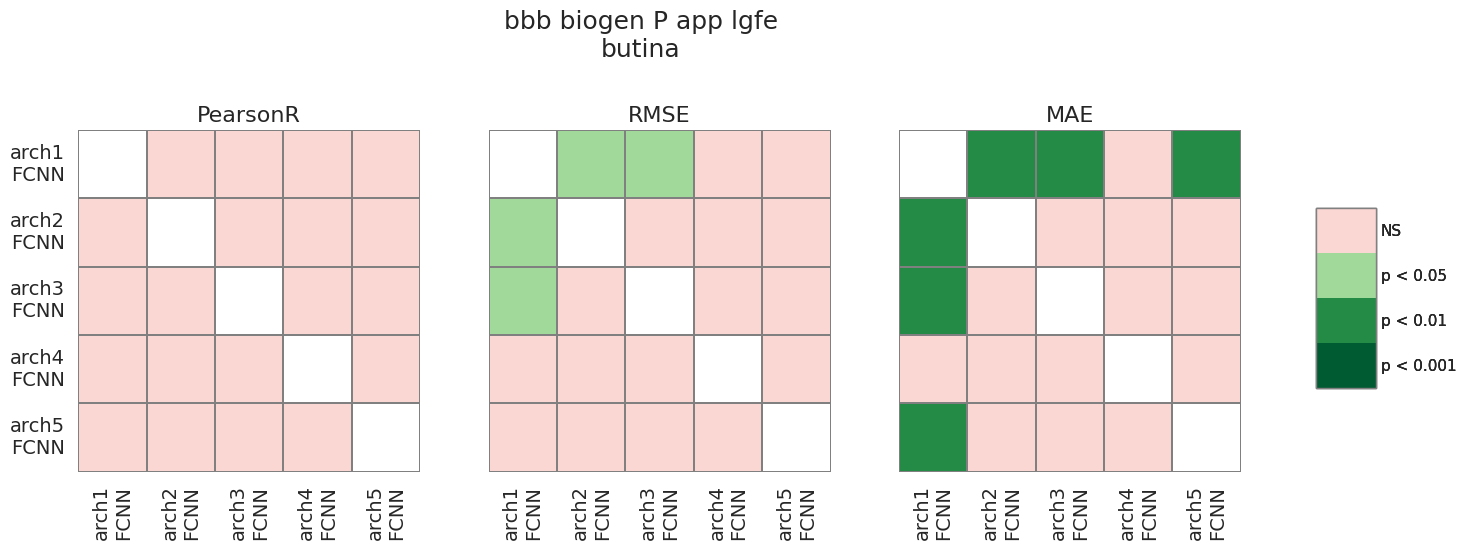

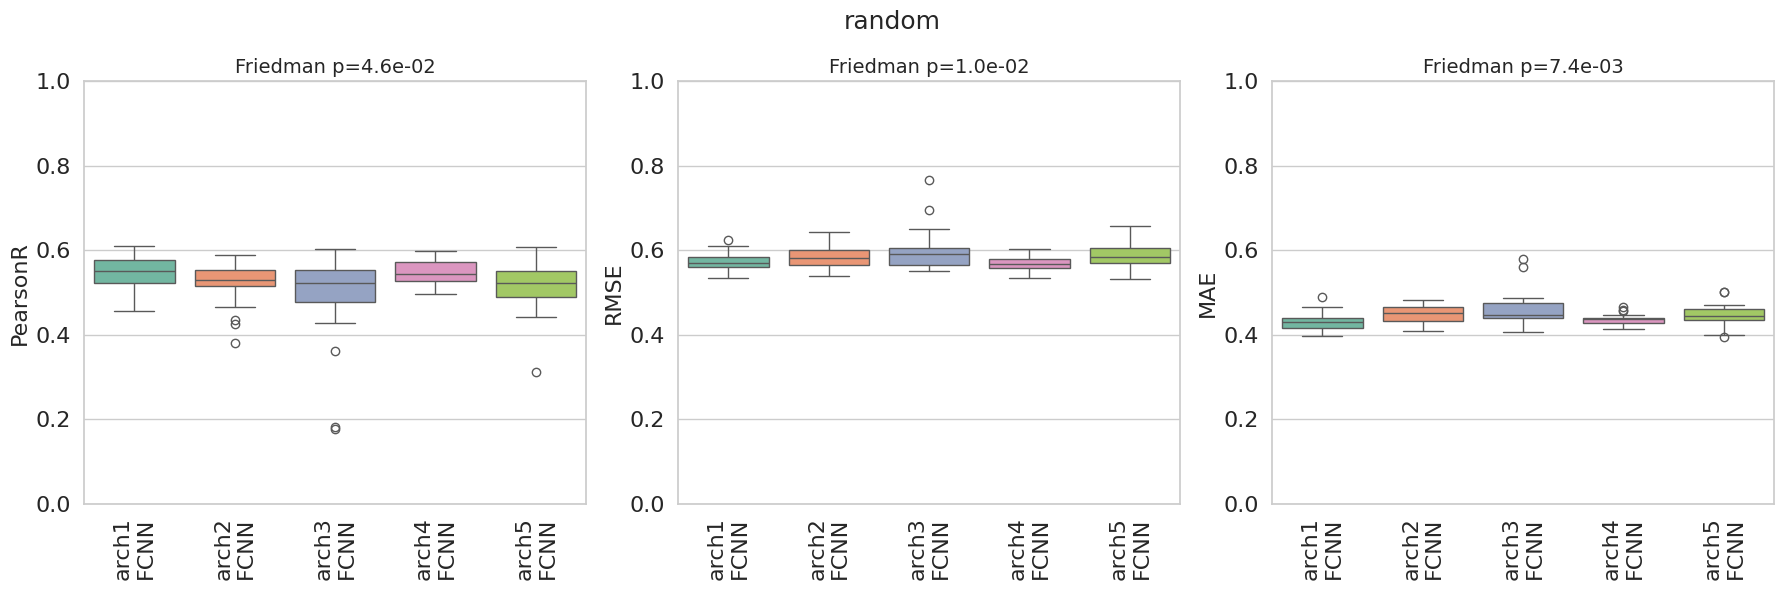

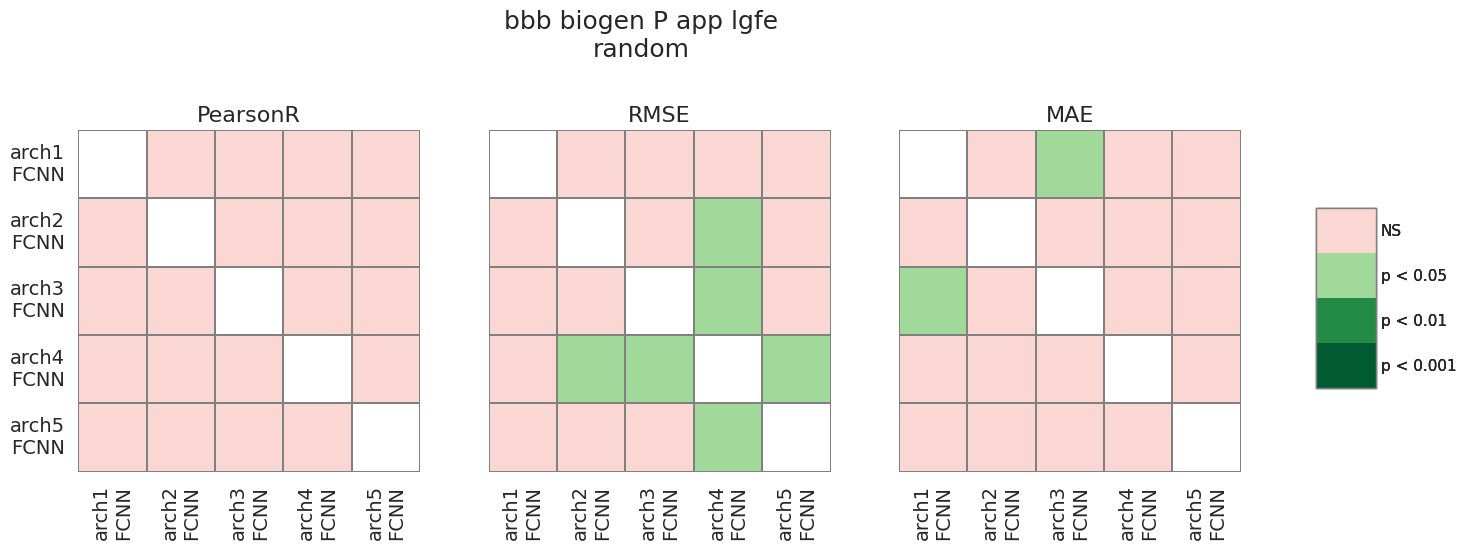

In [3]:
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    # levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    # print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/across_fcnn_archs_P_app")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/across_fcnn_archs_P_app")
        
export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots/across_fcnn_archs_P_app/Levene_variance_results.xlsx"
)

#### 1. B. FCNN Arch 1 seems like a good choice for further comparison since it has relatively better performace metrics and lower variablility compared to other architectures tested. 

In [4]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN-1/evaluation_*.csv"]]

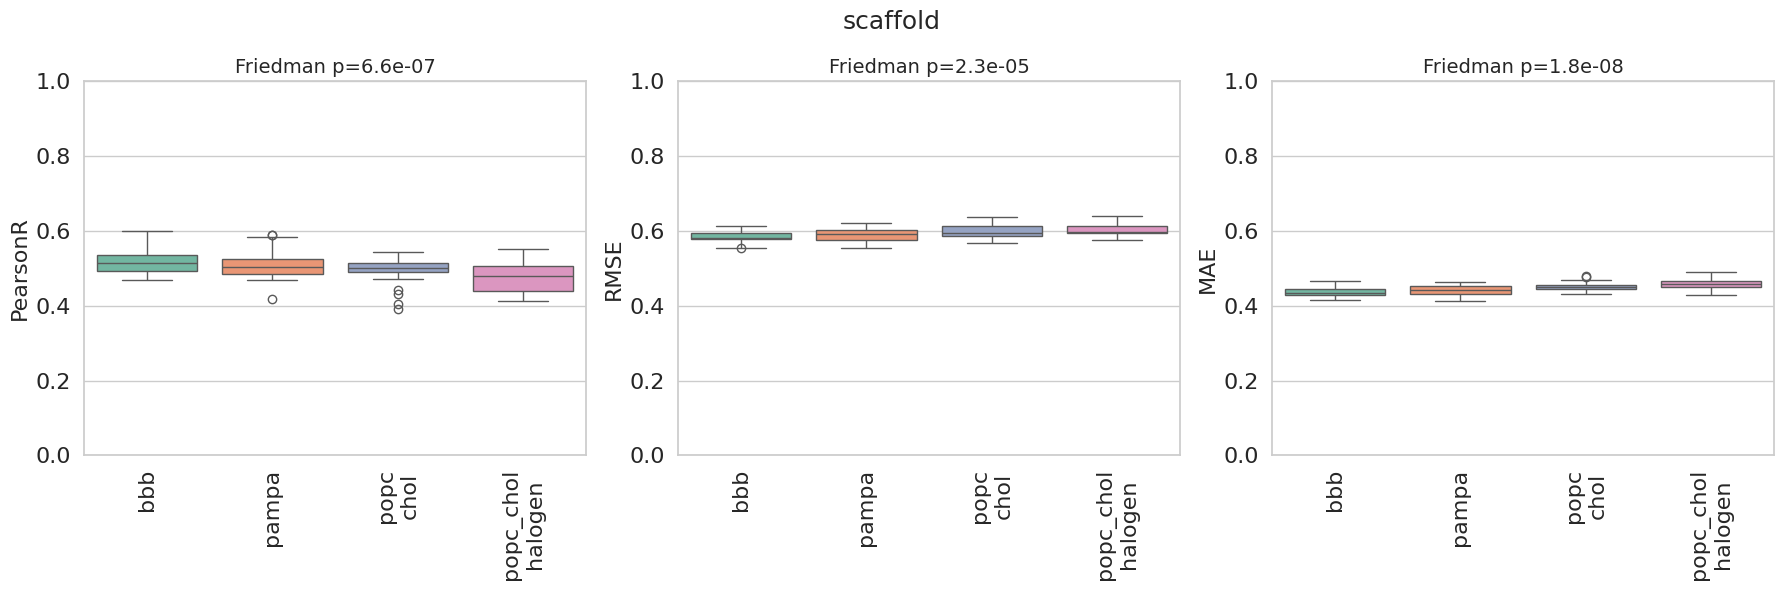

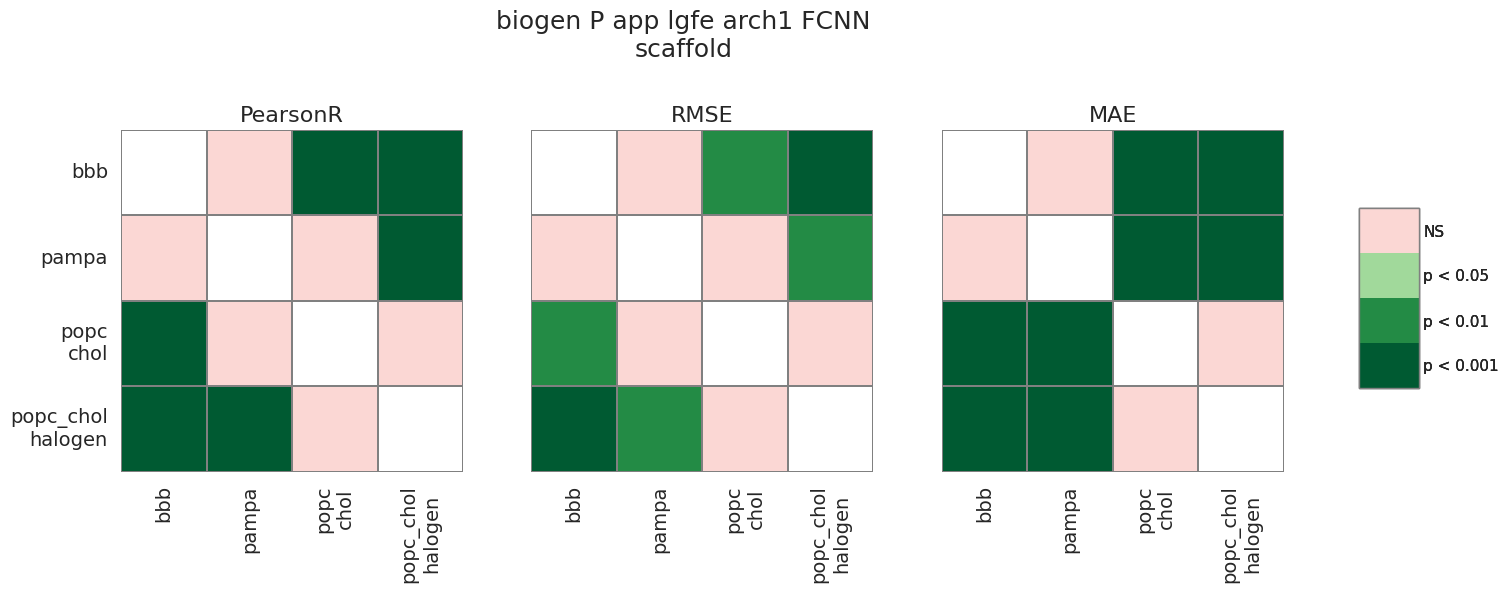

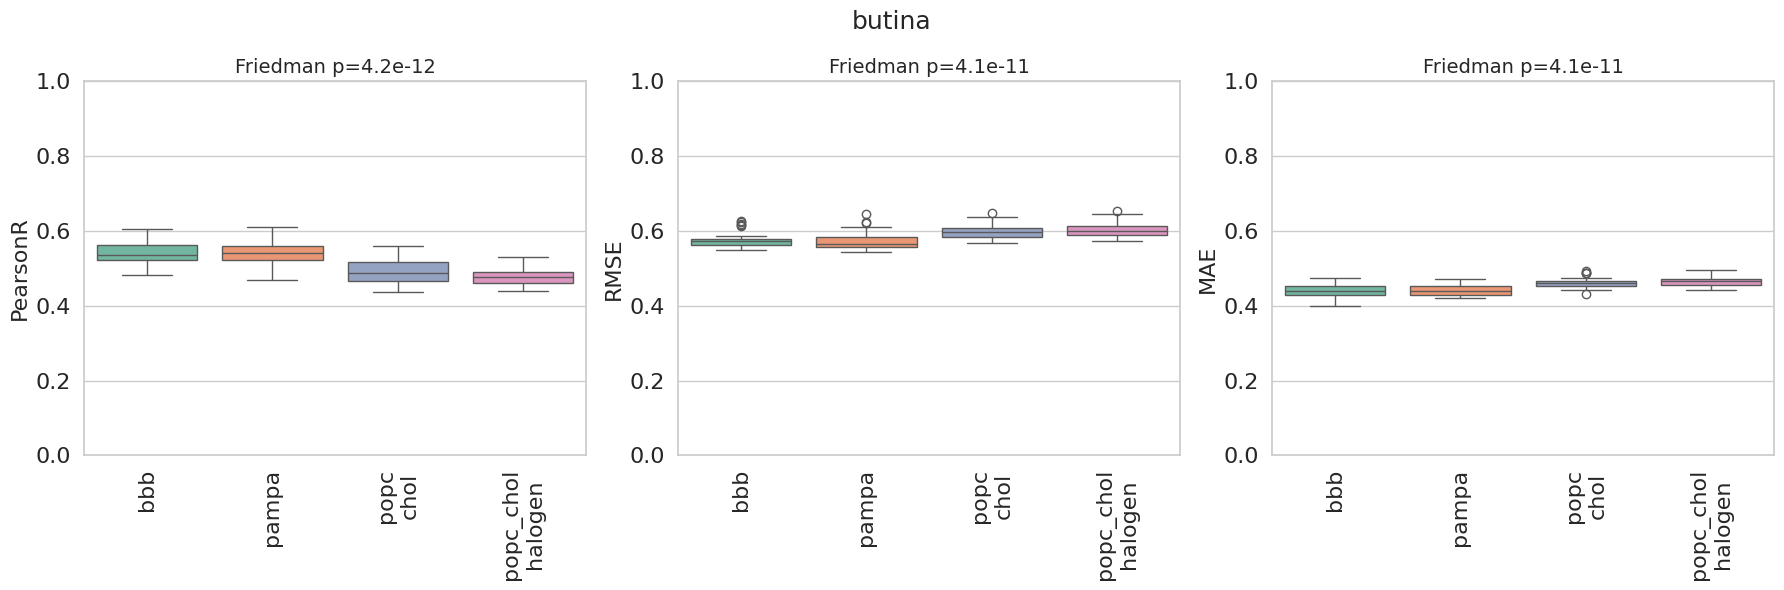

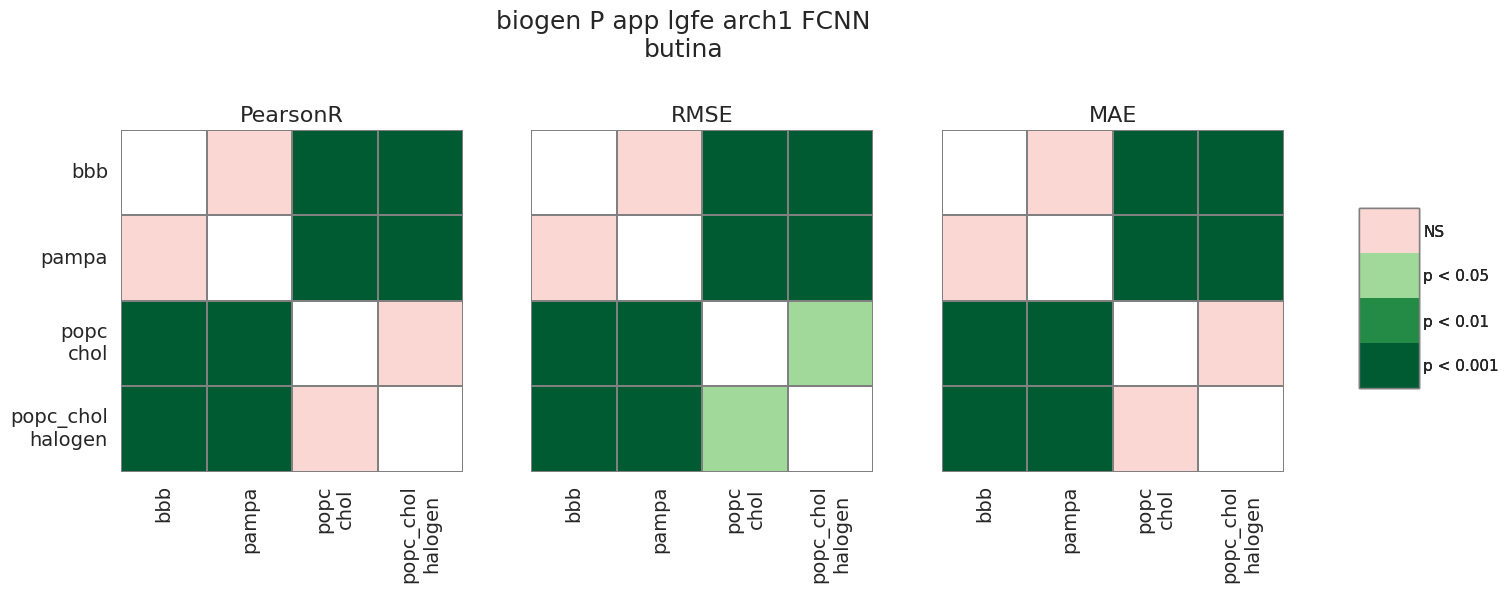

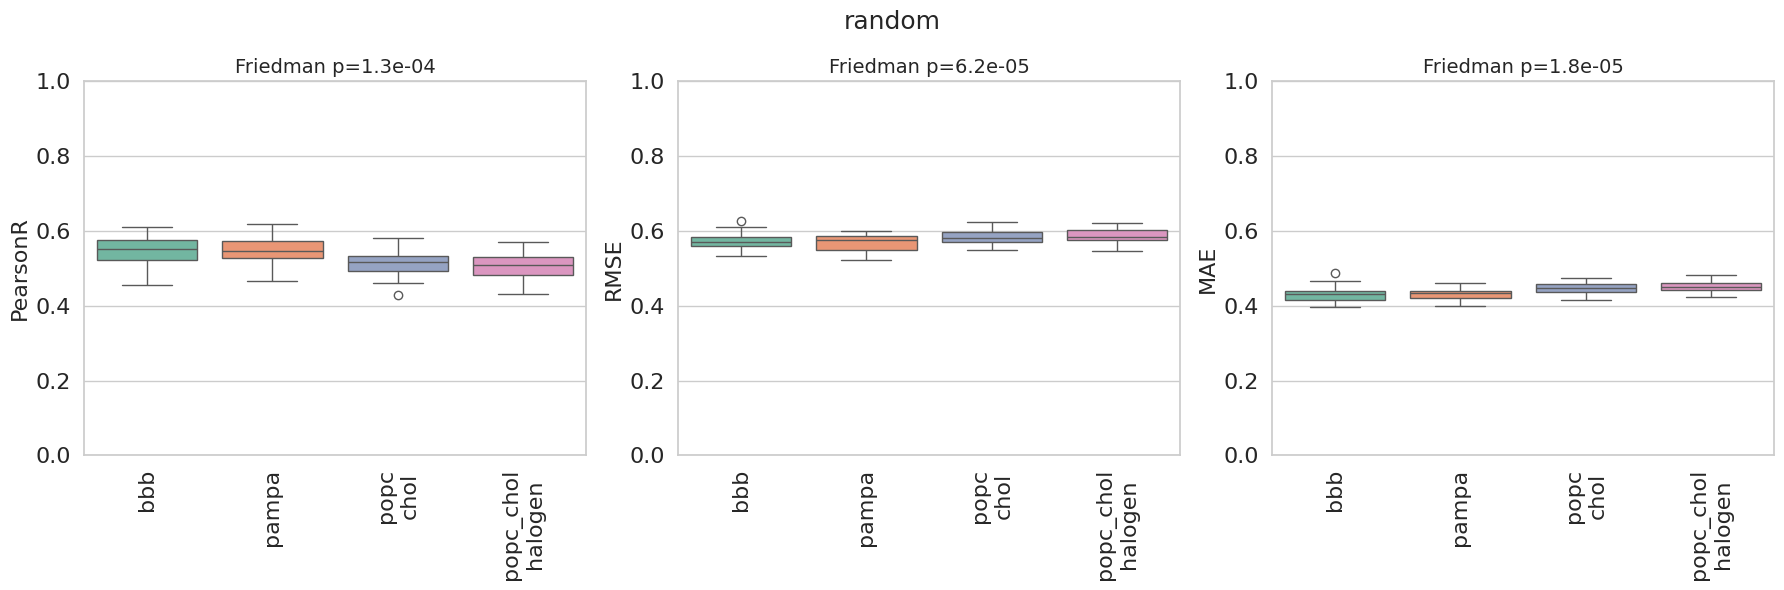

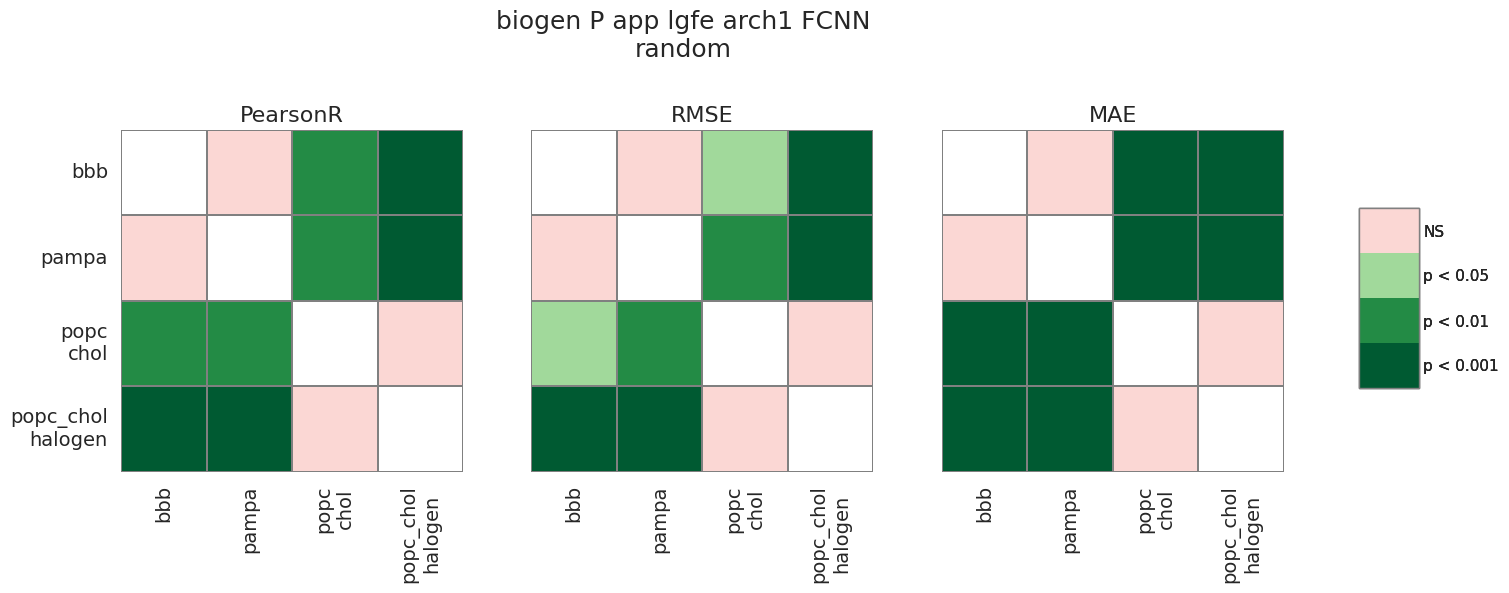

In [5]:
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    # print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/fcnn1_across_membs_P_app", common_prefix="-biogen-P_app_lgfe_arch1_FCNN")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/fcnn1_across_membs_P_app", common_prefix="-biogen-P_app_lgfe_arch1_FCNN")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots/fcnn1_across_membs_P_app/Levene_variance_results.xlsx"
)

In [ ]:
export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./fcnn1_across_membs/Levene_variance_results.xlsx"
)

TDLR: Both PAMPA and BBB models are better than simple POPC-CHOL models in terms of FCNN method

### 2. LightGBM

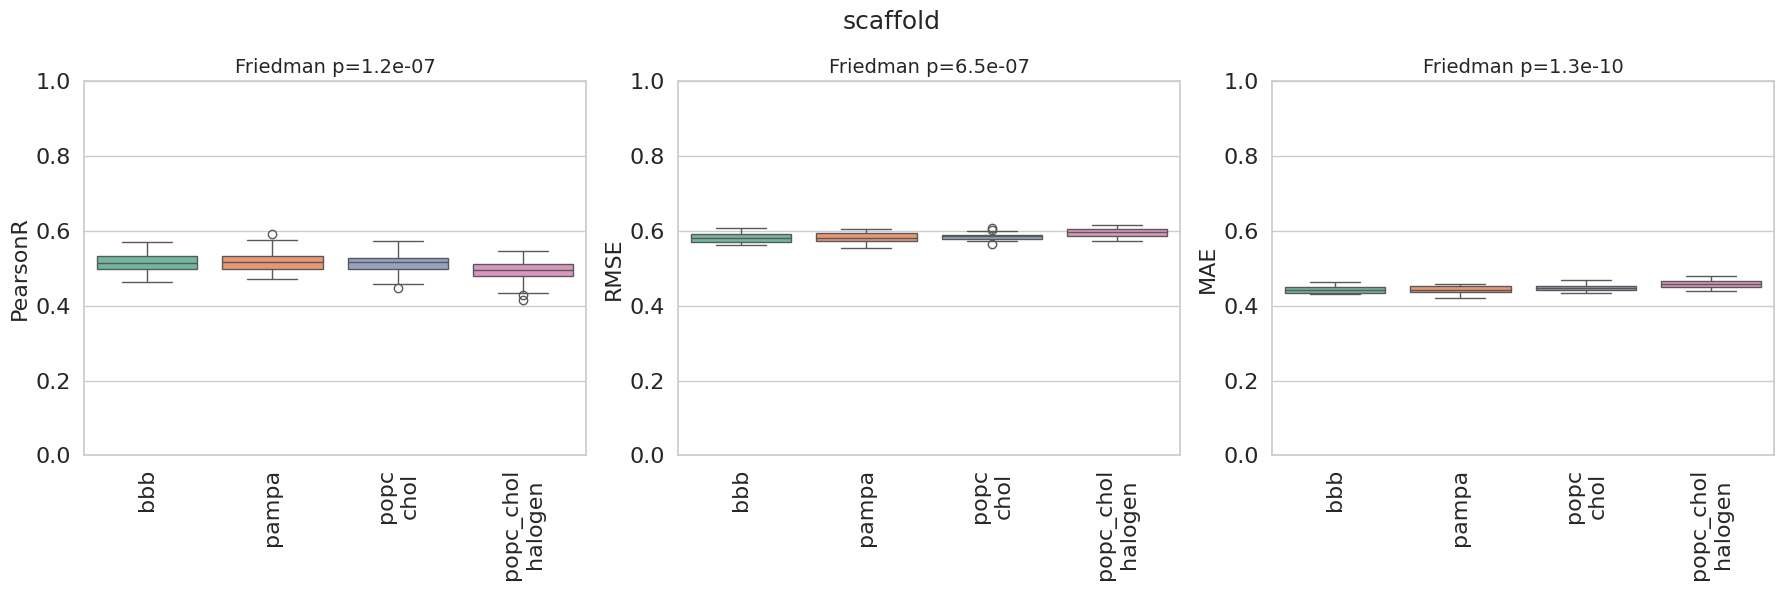

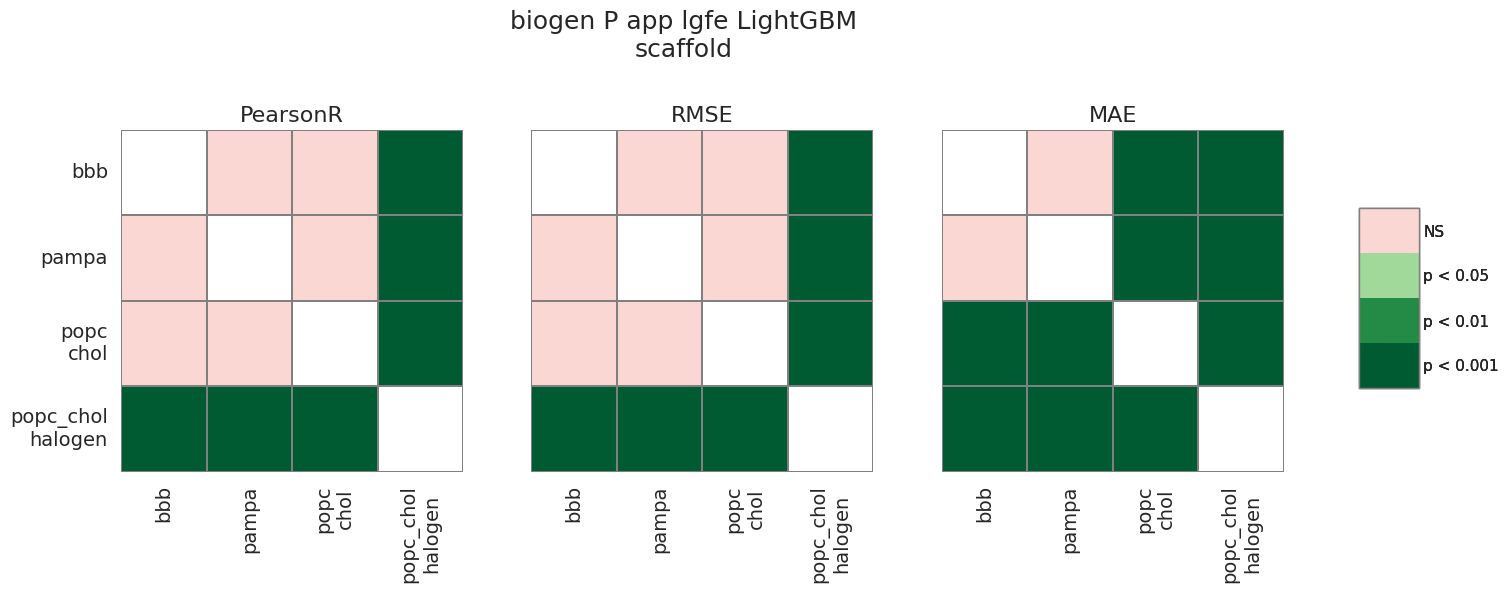

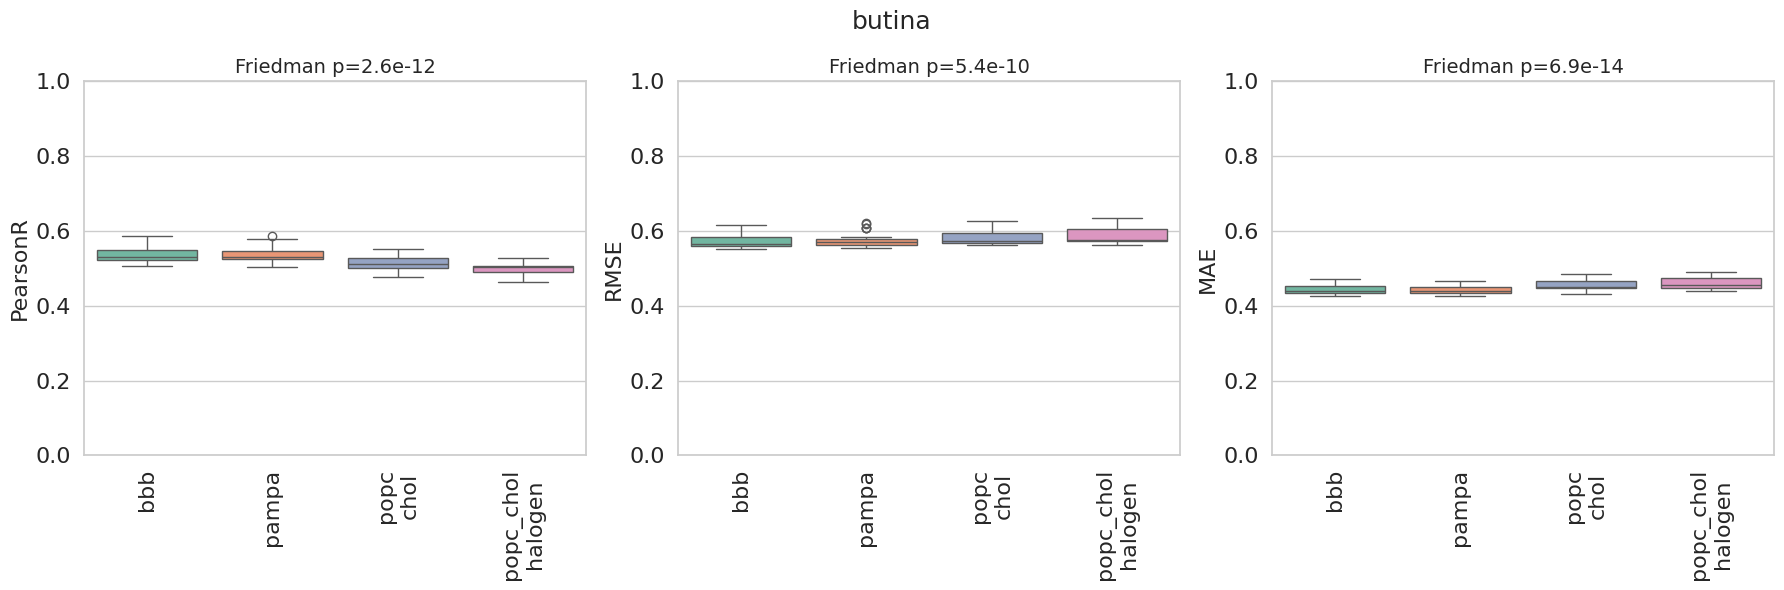

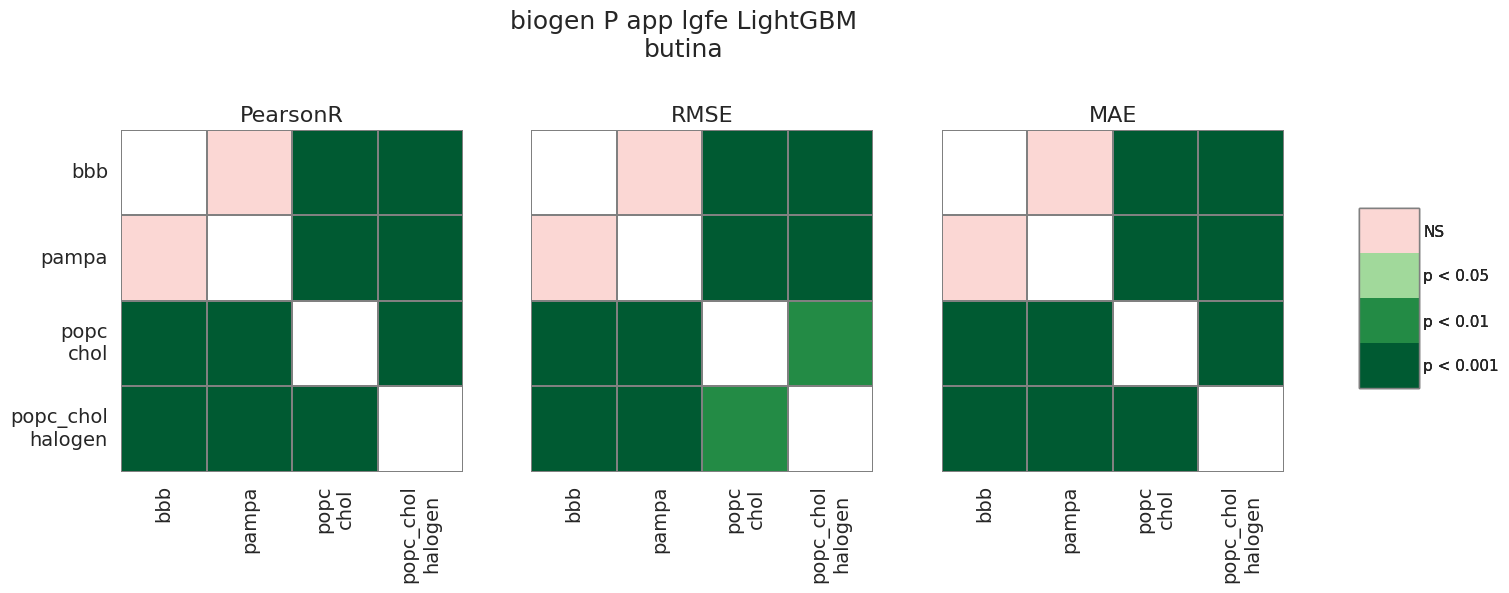

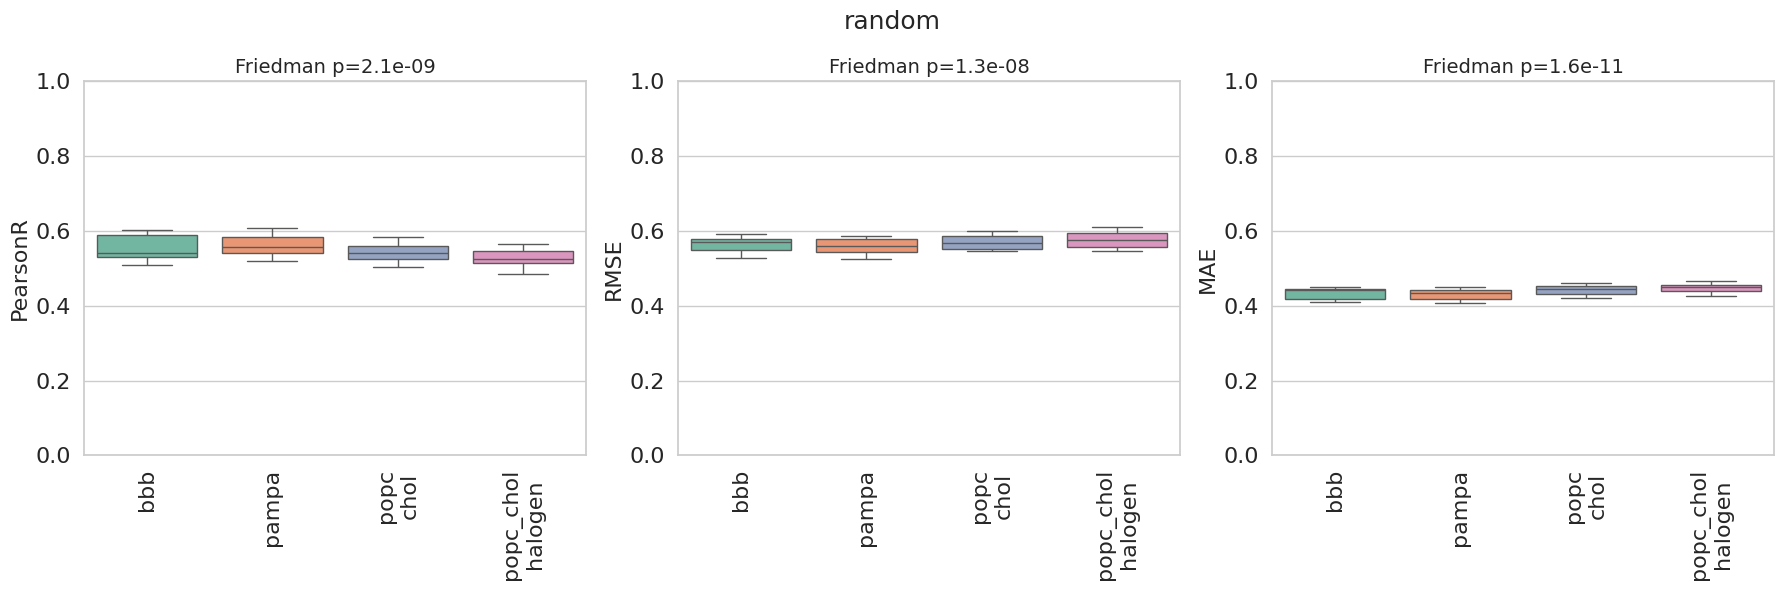

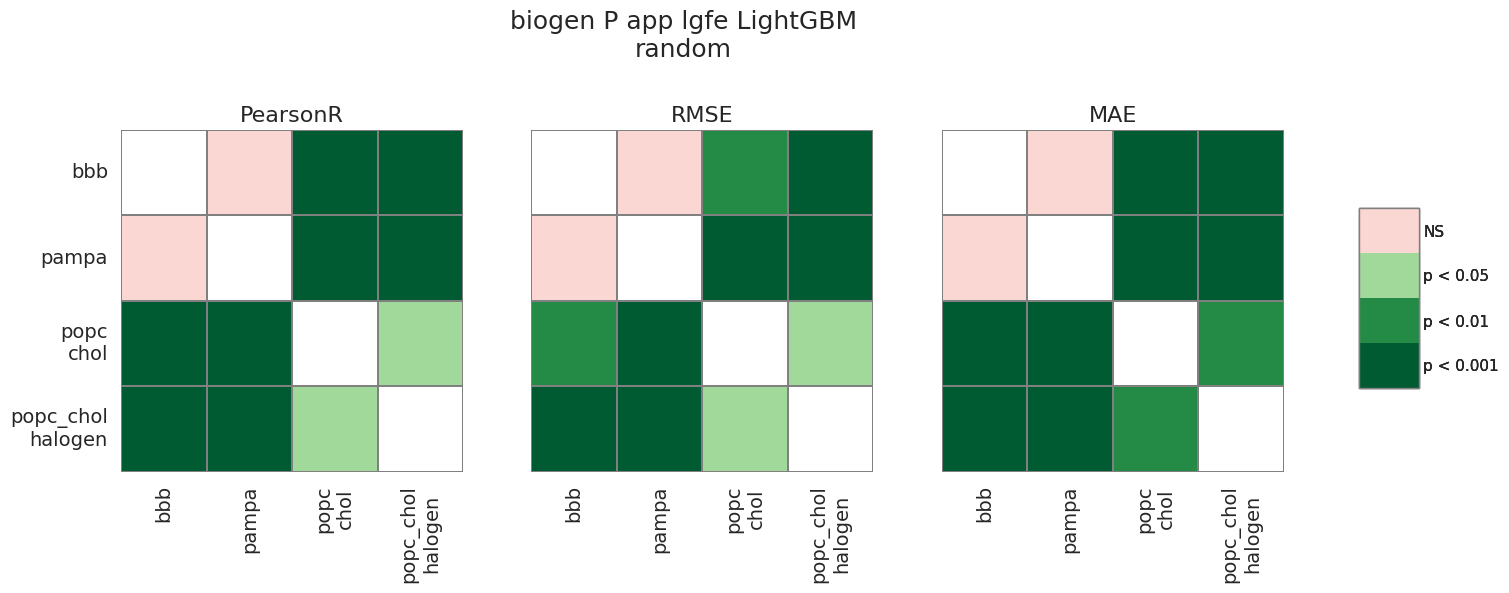

In [6]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_base/evaluation/LightGBM/evaluation_*.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    # metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    # levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    # print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/lgbm_across_membs_P_app", common_prefix="-biogen-P_app_lgfe_LightGBM")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/lgbm_across_membs_P_app", common_prefix="-biogen-P_app_lgfe_LightGBM")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots/lgbm_across_membs_P_app/Levene_variance_results.xlsx"
)

TDLR : Similar to FCNN, BBB and PAMPA models are better than POPC ones. Interestingly depending on the splitting strategy, there is a significant difference in performance between halogen maps and standard maps

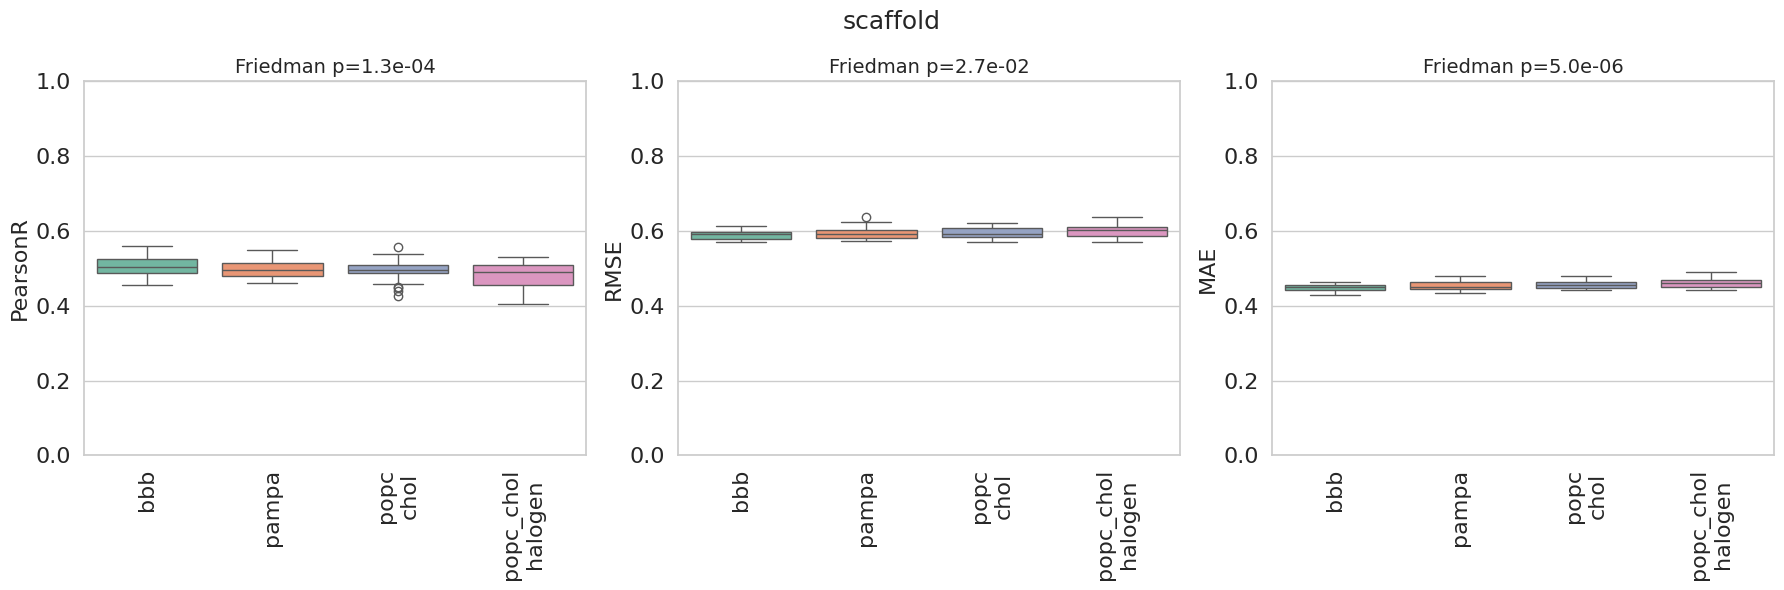

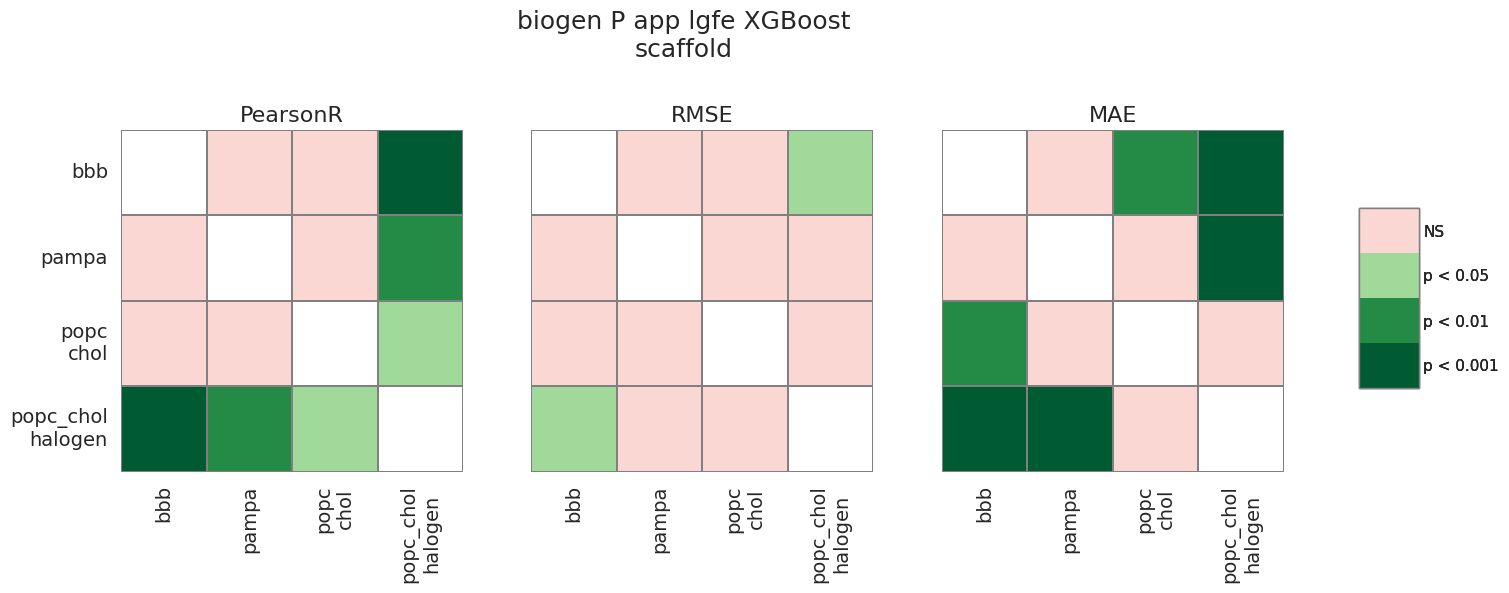

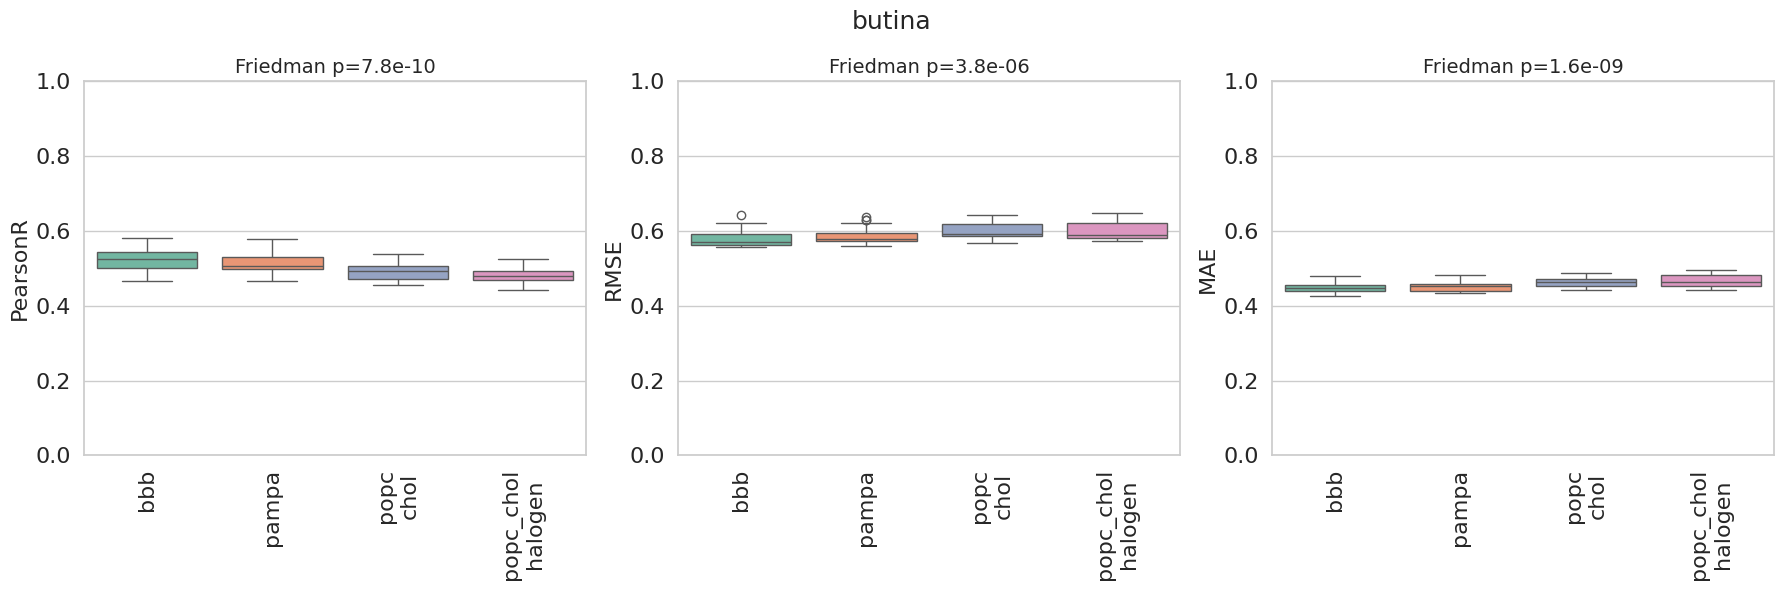

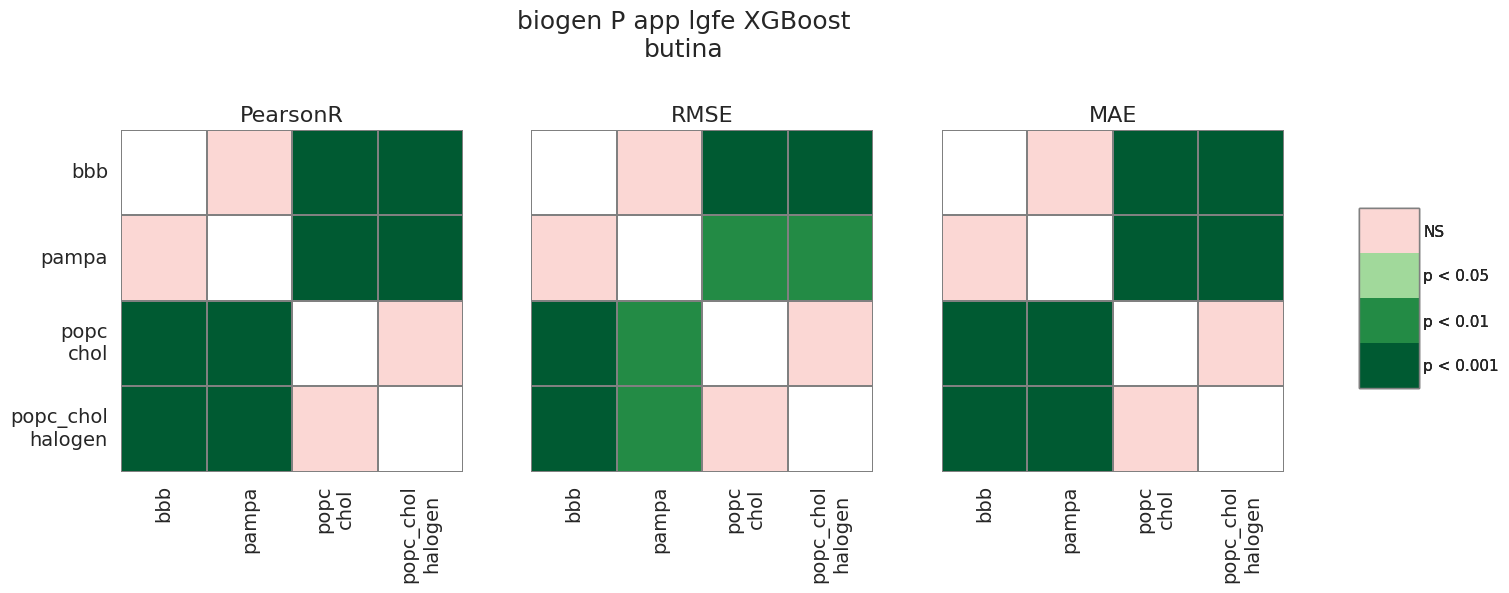

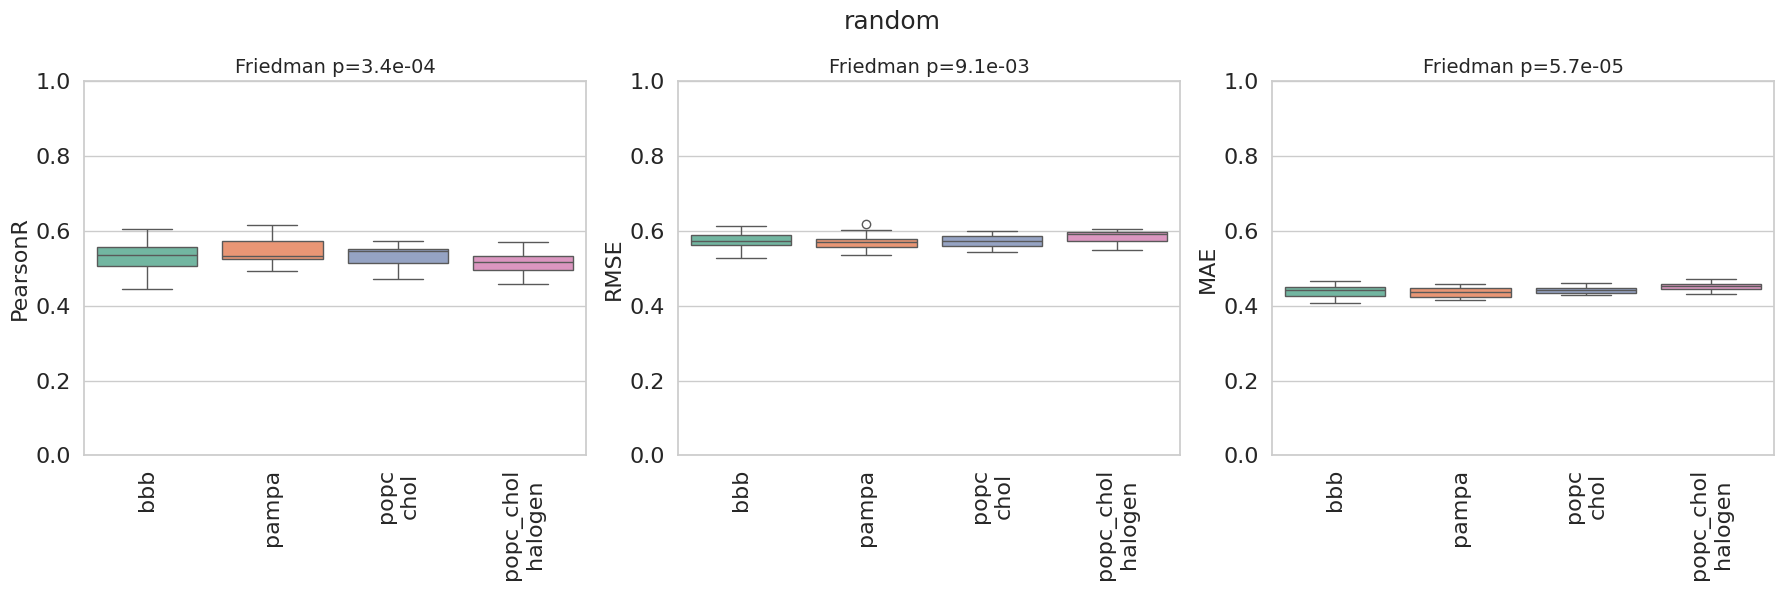

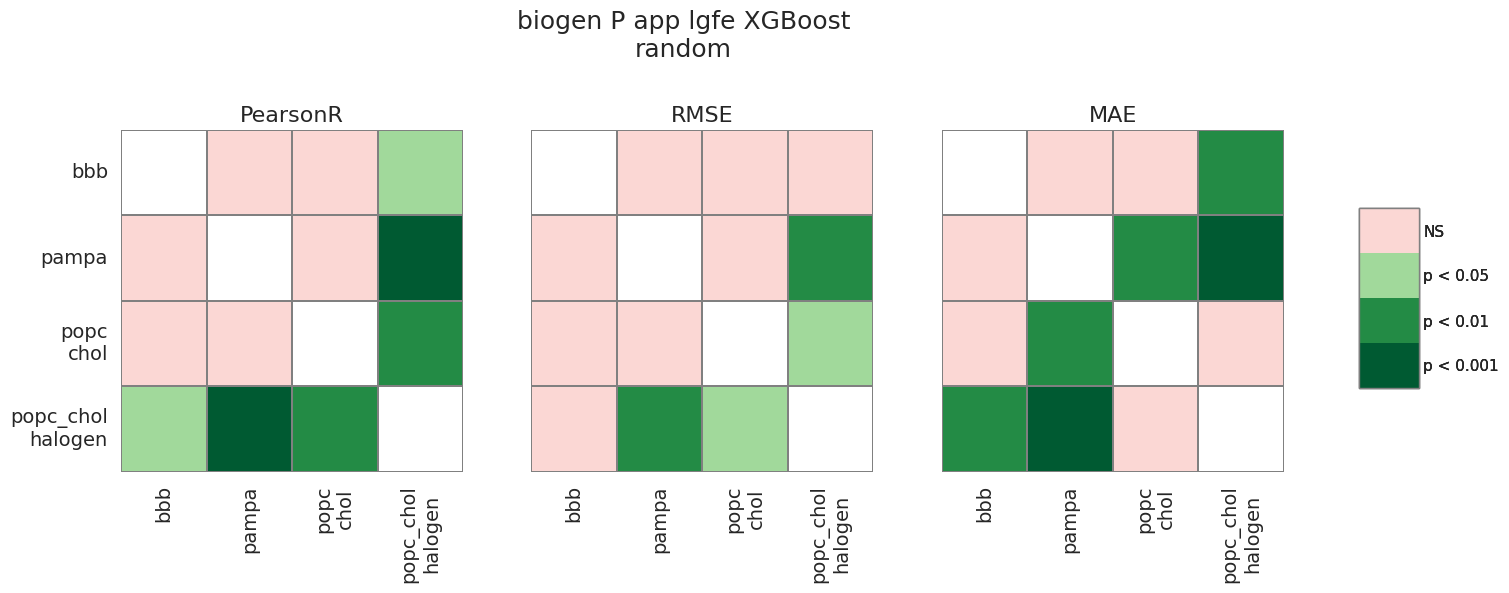

In [7]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_base/evaluation/XGBoost/evaluation_*.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    # metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    # levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    # print (Path(csv_file[0]).name)
    # print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/xgb_across_membs_P_app", common_prefix="-biogen-P_app_lgfe_XGBoost")
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/xgb_across_membs_P_app", common_prefix="-biogen-P_app_lgfe_XGBoost")

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots/xgb_across_membs_P_app/Levene_variance_results.xlsx"
)

TDLR: Same story : Adding halogen maps does not really improve the performance significantly but often reduce it

### 4. How about FCNN vs ensemble learning models?

evaluation_bbb.csv
       split       metric  levene_pvalue  max_over_min
0     butina           R2       0.036930      5.843999
1     butina         RMSE       0.992890      1.723878
2     butina          MAE       0.919729      1.893874
3     butina     PearsonR       0.067757      3.940335
4     butina  SpearmanRho       0.000238      7.535880
5     random           R2       0.218495      4.095634
6     random         RMSE       0.960401      1.922735
7     random          MAE       0.212149      4.358081
8     random     PearsonR       0.351889      3.349105
9     random  SpearmanRho       0.013175      8.601685
10  scaffold           R2       0.989701      1.925626
11  scaffold         RMSE       0.030851      3.674318
12  scaffold          MAE       0.525888      2.148965
13  scaffold     PearsonR       0.777302      2.431593
14  scaffold  SpearmanRho       0.416237      2.392241


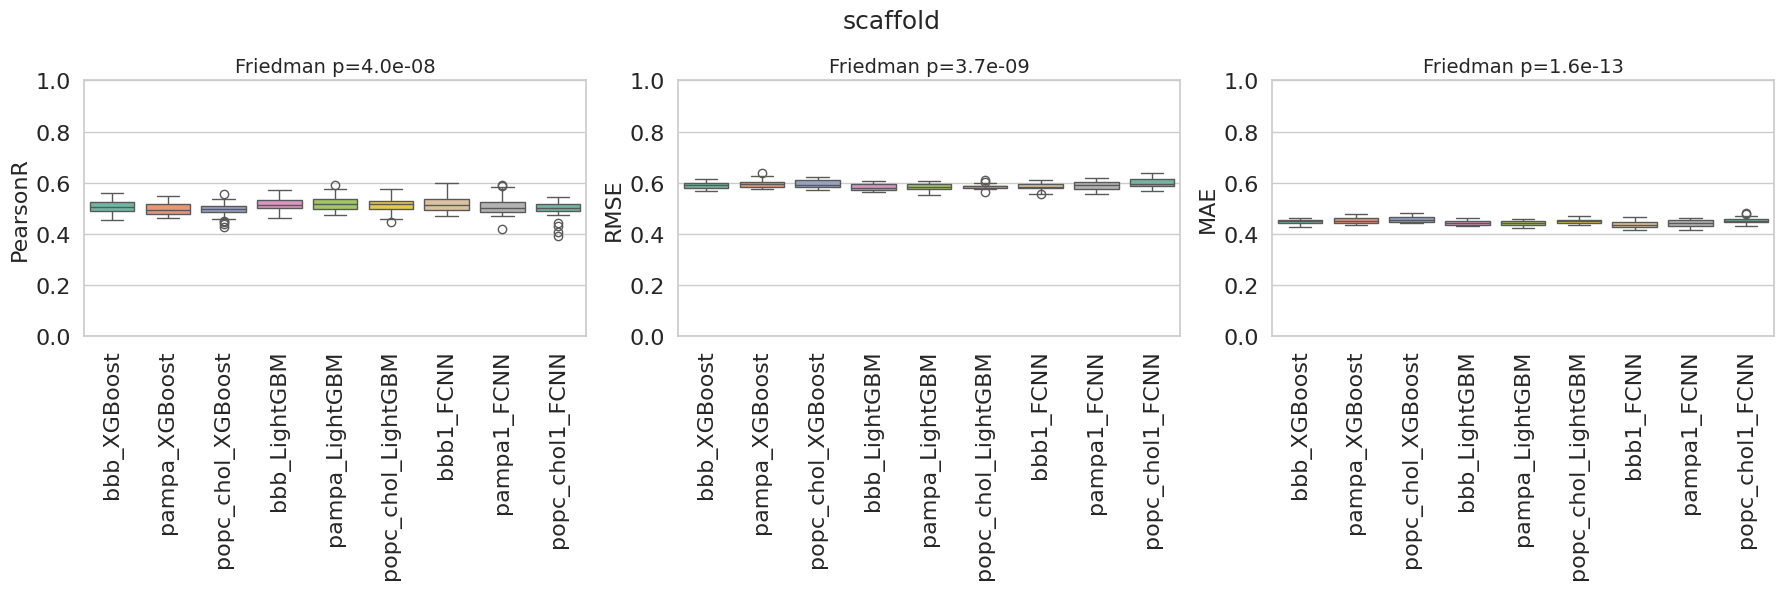

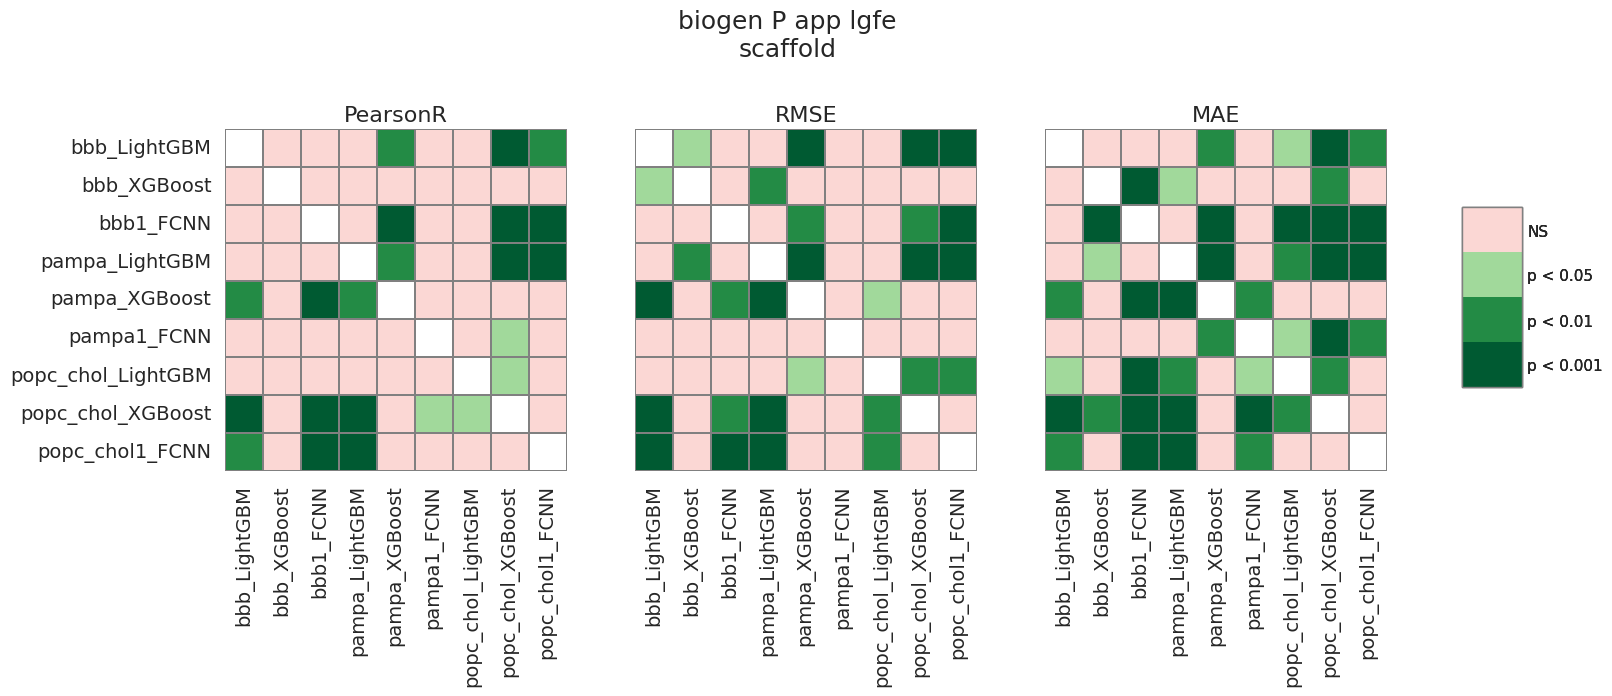

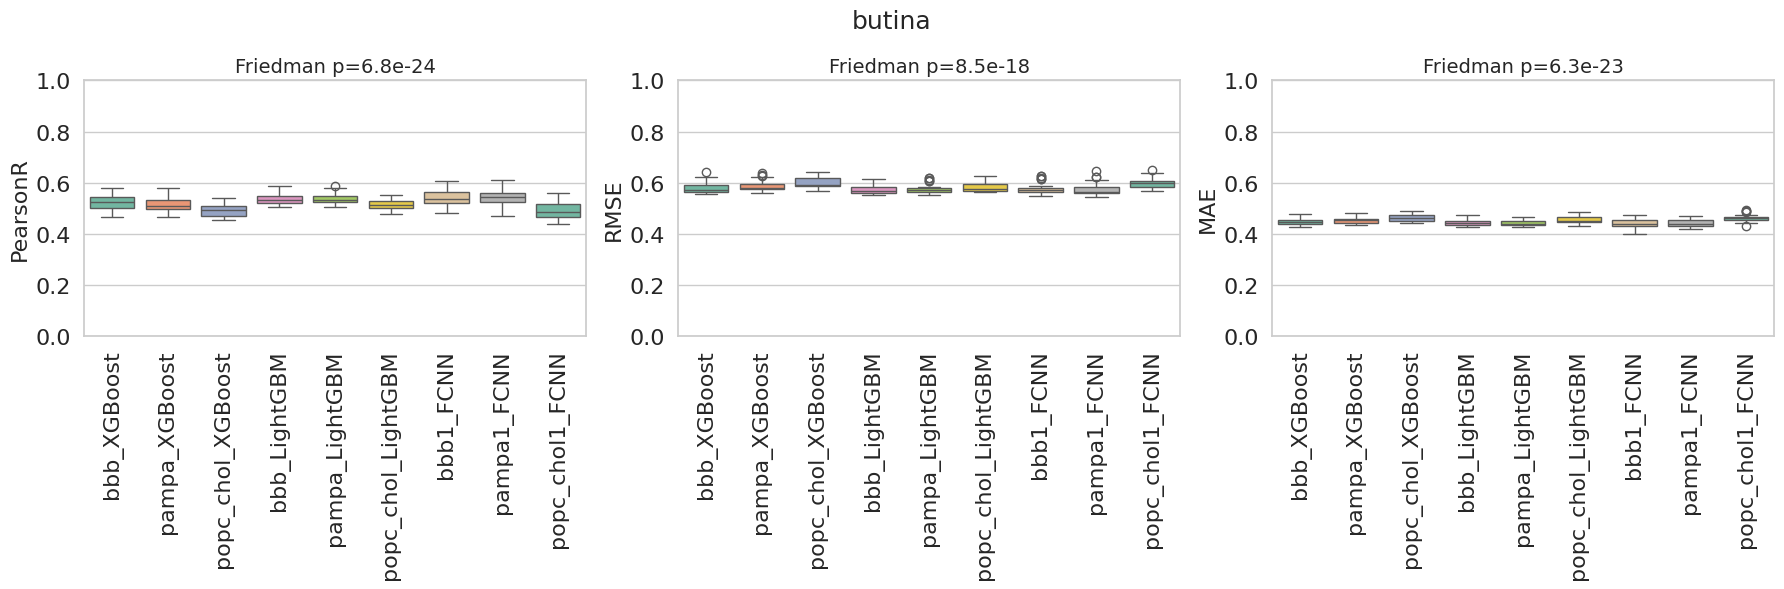

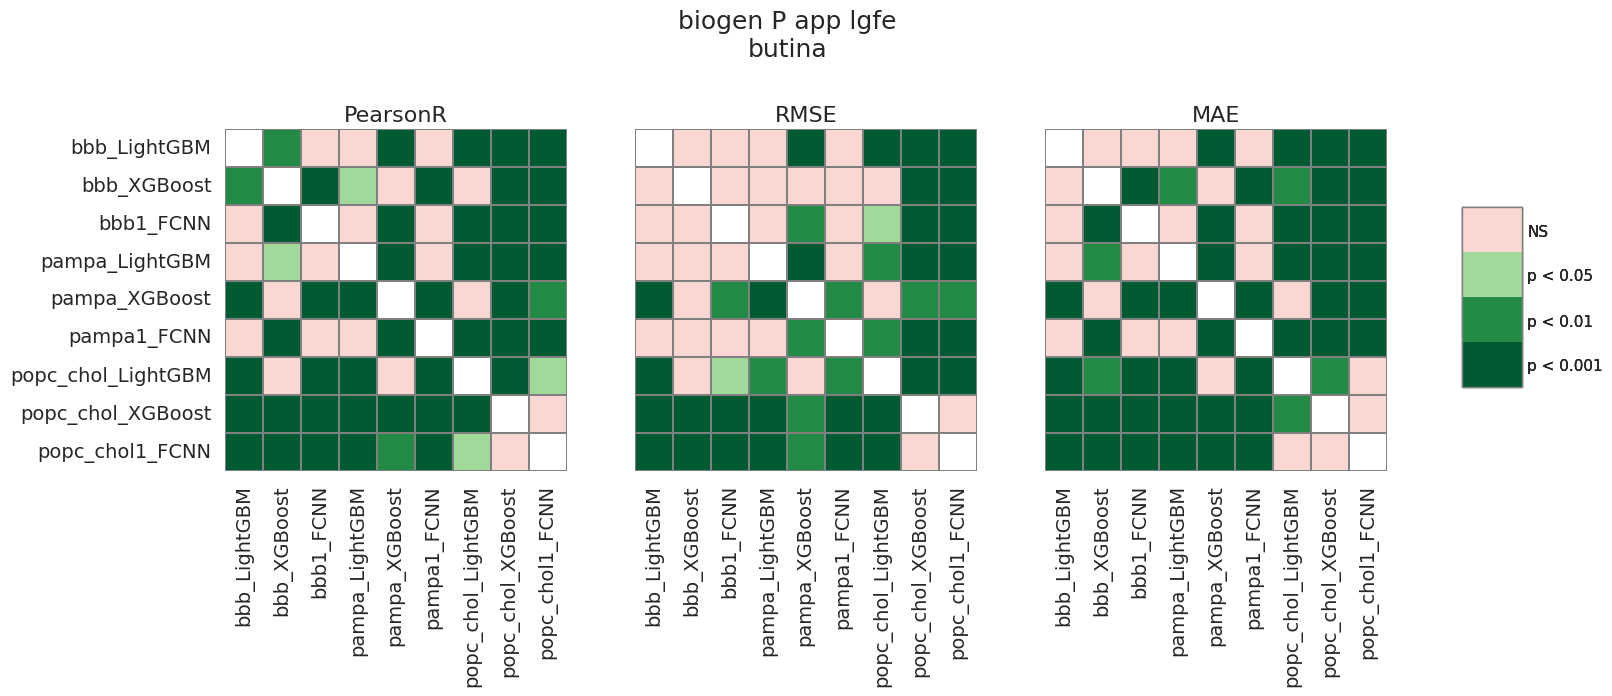

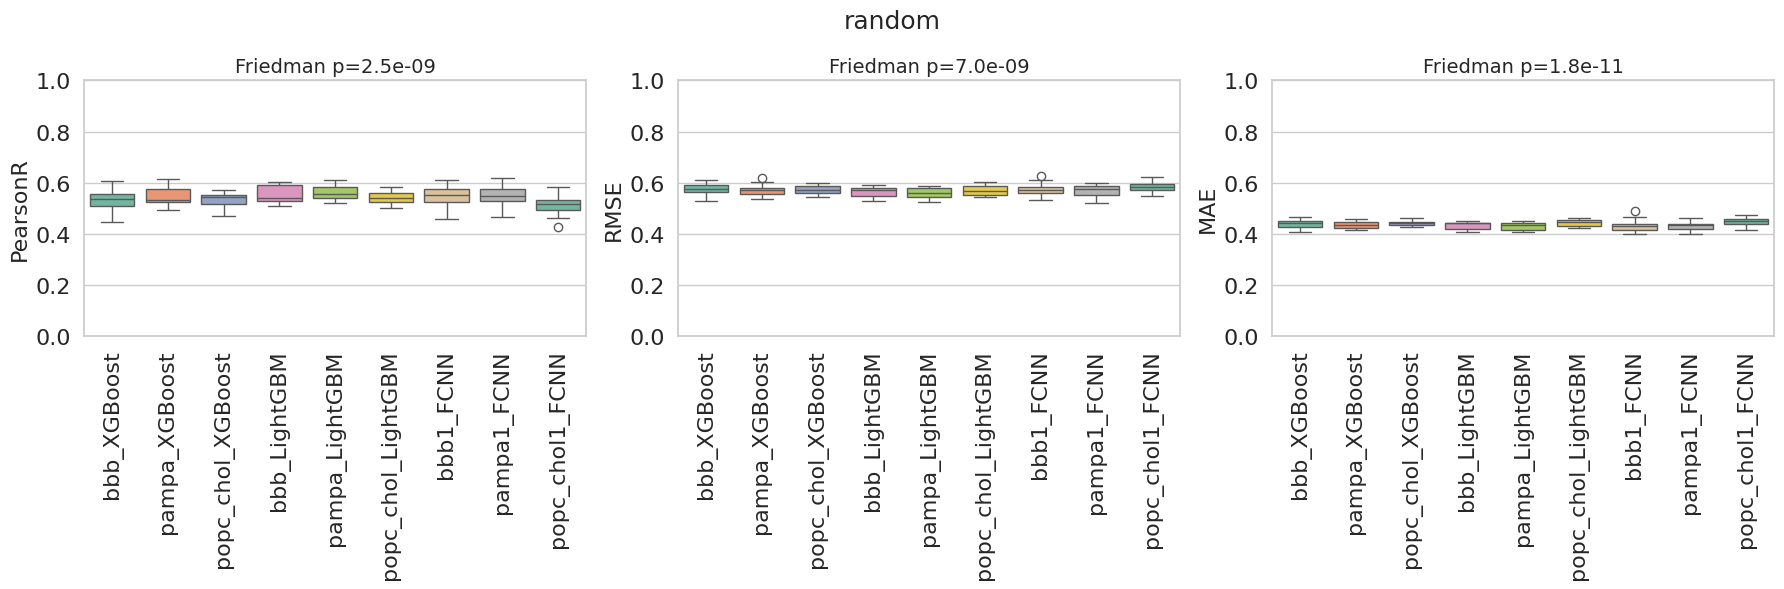

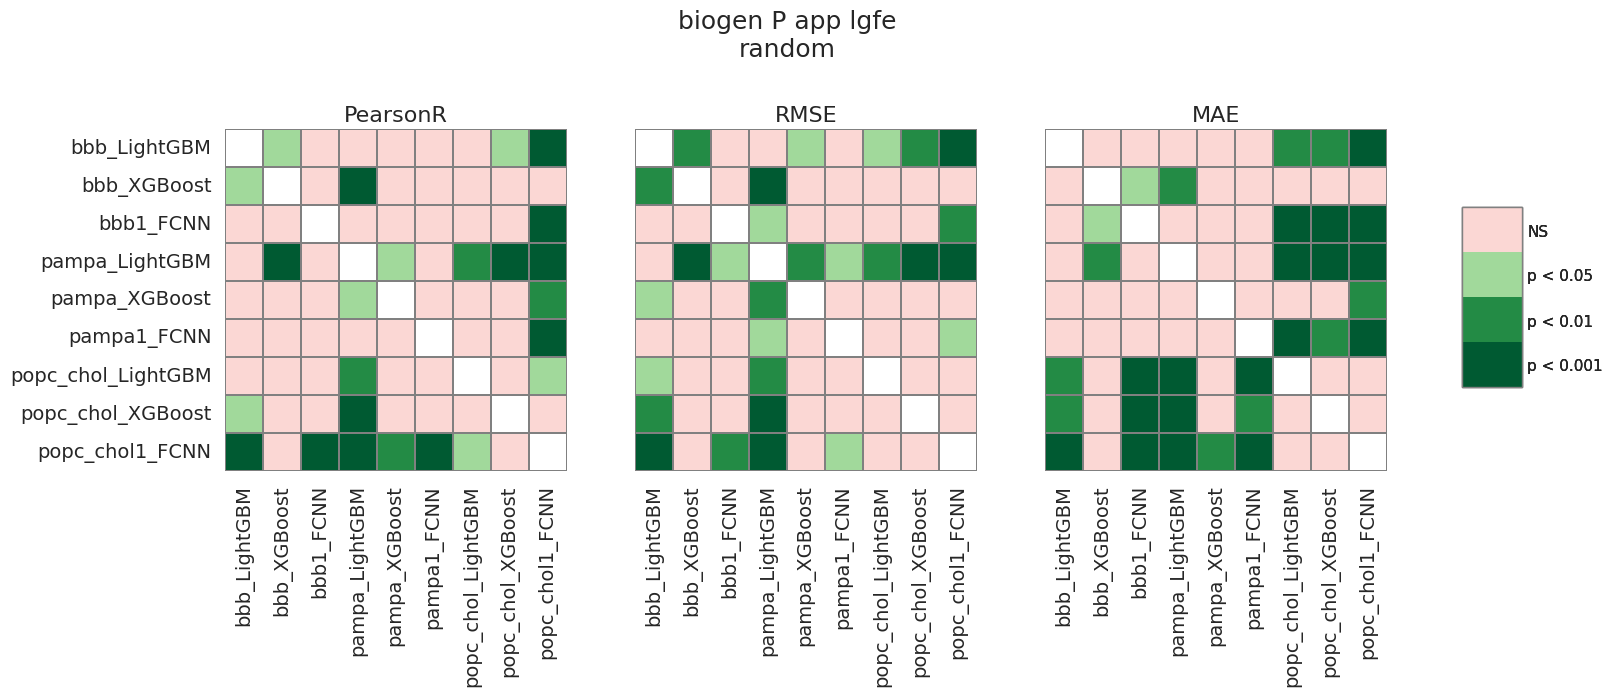

In [8]:
memb_csv_files = [["../ml-modeling-P_app_lgfe_biogen_base/evaluation/XGBoost/evaluation_bbb.csv",
                   "../ml-modeling-P_app_lgfe_biogen_base/evaluation/XGBoost/evaluation_pampa.csv",
                   "../ml-modeling-P_app_lgfe_biogen_base/evaluation/XGBoost/evaluation_popc_chol.csv",
                  "../ml-modeling-P_app_lgfe_biogen_base/evaluation/LightGBM/evaluation_bbb.csv",
                   "../ml-modeling-P_app_lgfe_biogen_base/evaluation/LightGBM/evaluation_pampa.csv",
                   "../ml-modeling-P_app_lgfe_biogen_base/evaluation/LightGBM/evaluation_popc_chol.csv",
                  "../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN-1/evaluation_bbb.csv",
                   "../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN-1/evaluation_pampa.csv",
                   "../ml-modeling-P_app_lgfe_biogen_base/evaluation/FCNN-1/evaluation_popc_chol.csv"]]
for csv_file in memb_csv_files:
    df = concat_metric_files(csv_file)
    # print (df.head())
    metric_ls_full = ['R2', 'RMSE', 'MAE', 'PearsonR', 'SpearmanRho']
    levene_variance_df = variance_analysis_by_split(df, metric_ls_full)
    print (Path(csv_file[0]).name)
    print (levene_variance_df)
    metric_ls = ['PearsonR', 'RMSE', 'MAE']
    split_ls = ['scaffold', 'butina', 'random']
    for split in split_ls:
        make_boxplots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/allmodels_across_membs_P_app", common_prefix="-biogen-P_app_lgfe", line_breaks=False)
        make_sign_plots_nonparametric(df.query("split == '" + split + "'"), metric_ls, prefix=split, outdir="./plots/allmodels_across_membs_P_app", common_prefix="-biogen-P_app_lgfe", line_breaks=False)

export_levene_results_to_excel(
    memb_csv_files,
    output_excel="./plots/allmodels_across_membs_P_app/Levene_variance_results.xlsx"
)